In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def plot_band(eigval_k,w=None,Erange=False,tag=None,c='k'):
    ks,Es = eigval_k.shape
    
    vals_all = np.sort(eigval_k.flatten())
    mid = Es * ks //2
    EF = (vals_all[mid] + vals_all[mid - 1]) / 2

    if type(w) != type(None):
        for i in range(Es):
            plt.scatter(np.arange(ks), eigval_k[:, i]-EF, s=0.2, c=w[:,i])
        plt.colorbar()
    else:
        for i in range(Es):
            plt.plot(np.arange(ks), eigval_k[:, i]-EF,c)

    plt.hlines(0,0,ks-1,colors='black', linestyles='dashed')
    plt.xlim(0,ks-1)
    if Erange:
        plt.ylim(-Erange,Erange)
    plt.ylabel('Energy (eV)')
    plt.title(tag)

### Basic setup

In [3]:
sx = np.array([[0,1],[1,0]],dtype=complex)
sy = np.array([[0,-1j],[1j,0]],dtype=complex)
sz = np.array([[1,0],[0,-1]],dtype=complex)
s0 = np.array([[1,0],[0,1]],dtype=complex)  

a = 2.46 # Å
a0 = a/np.sqrt(3) # Å
dc = 3.35 # Å
gamma_3 = 0
gamma_4 = 0
v3=gamma_3*np.sqrt(3)/2*a
v4=gamma_4*np.sqrt(3)/2*a

In [4]:
def gen_kpath(hyk, n=151, return_ticks_points=False):
    total_distance = 0
    for i in range(len(hyk)-1):
        segment_length = np.linalg.norm(np.array(hyk[i+1]) - np.array(hyk[i]))
        total_distance += segment_length
    avg_dist = total_distance / (n - 1)
    path = []
    ticks = [0]
    current_points = 0
    for i in range(len(hyk)-1):
        segment_length = np.linalg.norm(np.array(hyk[i+1]) - np.array(hyk[i]))
        segment_points = int(round(segment_length / avg_dist))
        if i == len(hyk) - 2:
            segment_points = n - current_points
        current_points += segment_points
        ticks.append(current_points)
        _path = np.linspace(hyk[i], hyk[i+1], segment_points, endpoint=(i+1)//(len(hyk)-1))
        path.append(_path)
    ticks[-1]-=1
    if return_ticks_points:
        return np.concatenate(path).reshape(-1, len(hyk[0])), ticks
    else:
        return np.concatenate(path).reshape(-1, len(hyk[0]))

In [5]:
def hexagonal_P(crystal=np.array([a,a,dc]),hex=np.array([90,90,120]),vacuum_z=False):
    alpha,beta,gamma = np.deg2rad(hex)
    vector_a = crystal[0]*np.array([1,0,0])
    vector_b = crystal[1]*np.array([np.cos(gamma),np.sin(gamma),0])
    # vector_c = crystal[2]*np.array([np.cos(beta),
                                    # (np.cos(alpha)-np.cos(beta)*np.cos(gamma))/np.sin(gamma),
                                    # (1+2*np.cos(alpha)*np.cos(beta)*np.cos(gamma)-np.cos(alpha)**2-np.cos(beta)**2-np.cos(gamma)**2)**0.5/np.sin(gamma)])
    vector_c = crystal[2]*np.array([0,0,1])
    P = np.row_stack((vector_a,vector_b,vector_c))
    P[2,2] = vacuum_z if vacuum_z else P[2,2]
    return P

In [6]:
def high_sym_k(P=None,frac=True):
    if P is None:
        P = hexagonal_P()
    a1,a2,a3 = P
    S0 = np.cross(a1, a2)@a3.T
    b1 = 2*np.pi*np.cross(a2, a3)/S0 # b1=[2pi/Ls,2pi/sqrt(3)Ls,0]
    b2 = 2*np.pi*np.cross(a3, a1)/S0 # b2=[0,4pi/sqrt(3)Ls,0]
    b3 = 2*np.pi*np.cross(a1, a2)/S0

    Γ = np.array([0,0,0])
    M = b1/2
    K = b1/3+b2/3
    A = b3/2
    H = K+A
    L = M+A
    Ms = b2/2
    Ks = 2*b1/3-b2/3
    Hs = Ks+A
    
    cart_kpts = {'Γ':Γ,'M':M,'K':K,'A':A,'H':H,'L':L,'Ms':Ms,'Ks':Ks,'Hs':Hs}
    
    if frac:
        B = np.column_stack((b1, b2, b3))
        frac_kpts = {label: np.linalg.solve(B, k) for label, k in cart_kpts.items()}
        return frac_kpts
    else:
        return cart_kpts

In [7]:
def f_theta(m,r=1):
    return (180/np.pi)*np.arccos((3*m**2+3*m*r+(r**2)/2)/(3*m**2+3*m*r+r**2))

### BZ and integrate region

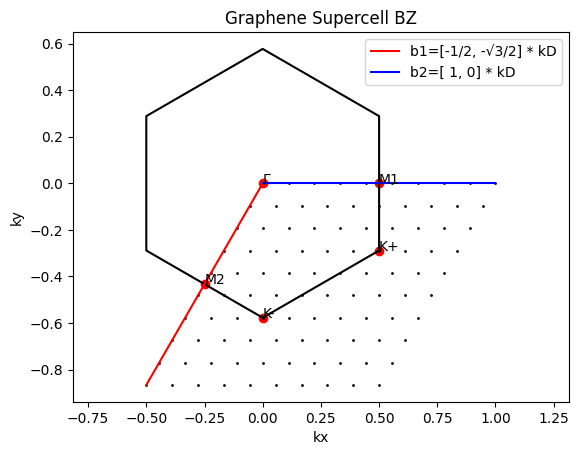

In [8]:
def plot_BZ(kD,full_inf=False):
    b1 = np.array([-0.5, -np.sqrt(3)/2]) * np.sqrt(3) * kD
    b2 = np.array([ 1.0,  0.0         ]) * np.sqrt(3) * kD
    
    corners = np.array([
        (2*b1 +   b2)/3,
        (  b1 + 2*b2)/3,
        (- b1 +   b2)/3,
        (-2*b1-   b2)/3,
        (- b1 - 2*b2)/3,
        (  b1 -   b2)/3,
        (2*b1 +   b2)/3,
    ])
    
    plt.plot(corners[:,0],corners[:,1],'k-')
    plt.plot([0, b1[0]], [0, b1[1]], "r-", label='b1=[-1/2, -√3/2] * kD')
    plt.plot([0, b2[0]], [0, b2[1]], "b-", label='b2=[ 1, 0] * kD')
    plt.axis("equal")
    
    if full_inf:
        _kpt = np.array([
            [ 0  , 0  ], # Γ
            [ 2/3, 1/3], # K-
            [ 1/3, 2/3], # K+
            [ 0  , 1/2], # M
            [ 1/2, 0  ], # M'
            # [ 1/3, 1/3], # K
        ])
        xtk = ['Γ','K-','K+','M1','M2','K']
        
        B = np.c_[b1,b2]
        kpt = np.array([B@k for k in _kpt])
        
        for i in range(len(_kpt)):
            plt.scatter(kpt[i,0],kpt[i,1],c='r')
            plt.text(kpt[i,0],kpt[i,1],f'{xtk[i]}')
            
        kn = np.linspace(0,1,10)
        x,y = np.meshgrid(kn,kn)
        X = x * b1[0] + y * b2[0]
        Y = x * b1[1] + y * b2[1]
        plt.scatter(X,Y,c='k',s=1)
        plt.xlabel("kx")
        plt.ylabel("ky")
        plt.title("Graphene Supercell BZ")
        plt.legend()
        # plt.show()

plot_BZ(1/np.sqrt(3),full_inf=1)

In [9]:
def system_in(nlayer,reverse=1, twist=1):
    # assert nlayer%2==0, 'The number of the layers should be even'
    slg = nlayer//2 if twist else nlayer
    ang = [0] * slg + [1] * (nlayer - slg)
    seq1 = ['A', 'B', 'C'] * (slg // 3) + ['A', 'B', 'C'][:slg % 3]
    seq2 = ['A', 'B', 'C'] * ((nlayer-slg) // 3) + ['A', 'B', 'C'][:(nlayer-slg) % 3]
    seq2 = seq2[::-1] if reverse else seq2
    seq = seq1 + seq2
    # ratio = [1] * (nlayer - 1)
    return ang, seq#, ratio

In [10]:
def moire_len(theta):
    a1 = np.array([ 0.5, np.sqrt(3) / 2]) * a
    a2 = np.array([-0.5, np.sqrt(3) / 2]) * a
    K_valley  = (4 * np.pi) / (3 * a) * np.array([ 1.0, 0.0])
    Kp_valley = (4 * np.pi) / (3 * a) * np.array([-1.0, 0.0])
    
    rot1 = np.array([
        [np.cos(theta / 2), -np.sin(theta / 2)],
        [np.sin(theta / 2),  np.cos(theta / 2)]
    ])
    rot2 = np.array([
        [ np.cos(theta / 2), np.sin(theta / 2)],
        [-np.sin(theta / 2), np.cos(theta / 2)]
    ])

    qb = np.dot(rot2, K_valley) - np.dot(rot1, K_valley)
    kD = np.linalg.norm(qb)
    return kD

In [11]:
def get_hk(km, valley, theta, nlayer, E_field=0, sub_pot=[0,0], disorder=np.zeros((2,2))):
    ang, seq = system_in(nlayer)
    kD = moire_len(theta)
    
    b1m = np.array([-0.5, -np.sqrt(3)/2]) * np.sqrt(3) * kD
    b2m = np.array([ 1.0,  0.0         ]) * np.sqrt(3) * kD
    
    K_valley1 = np.array([np.sqrt(3)/2, 0.5]) * kD
    K_valley2 = np.array([np.sqrt(3)/2,-0.5]) * kD
    
    # Generate Q-vectors
    Nqvec = (2 * Qcut + 1) ** 2
    qvecs = np.mgrid[-Qcut:Qcut+1, -Qcut:Qcut+1].reshape(2,Nqvec)
    
    Ndim = 2 * Nqvec * nlayer
    
    # mono-layer graphene Hamiltonian
    # H(k)=-vf*(valley*sx-k*sy)
    Hmnk = np.zeros((Ndim,Ndim),dtype=complex)

    phi = valley*2*np.pi/3
    T1 = np.array([[u_AA,u_AB],[u_AB,u_AA]],dtype=complex)
    T2 = np.array([[u_AA,u_AB*np.exp( 1j*phi)],[u_AB*np.exp(-1j*phi),u_AA]])
    T3 = np.array([[u_AA,u_AB*np.exp(-1j*phi)],[u_AB*np.exp( 1j*phi),u_AA]])

    # diagonal term: intra-layer hopping
    for ilayer in range(nlayer):
        for iq in range(Nqvec):
            qvec = qvecs[:, iq]
            if ang[ilayer]:
                kvec = -K_valley1 * valley + (km[0] + qvec[0]) * b1m + (km[1] + qvec[1]) * b2m
            else:
                kvec = -K_valley2 * valley + (km[0] + qvec[0]) * b1m + (km[1] + qvec[1]) * b2m
            H_SLG = vf * (kvec[0] * valley * sx - kvec[1] * sy)
            H_SLG -= E_field * (ilayer - nlayer / 2.0) * dc * s0
            idx1 = ilayer * Nqvec * 2 + iq * 2
            Hmnk[idx1:idx1+2, idx1:idx1+2] = H_SLG + np.diag(sub_pot) #+ (disorder+disorder.conj().T)/2

    # diagonal term: inter-layer hopping for non-TBG pair layers
    for ilayer in range(nlayer - 1):
        if ang[ilayer] == ang[ilayer+1]:
            for iq in range(Nqvec):
                idx1 = ilayer * Nqvec * 2 + iq * 2
                idx2 = (ilayer + 1) * Nqvec * 2 + iq * 2
                qvec = qvecs[:, iq]
                if ang[ilayer]:
                    kvec = -K_valley1 * valley + (km[0] + qvec[0]) * b1m + (km[1] + qvec[1]) * b2m
                else:
                    kvec = -K_valley2 * valley + (km[0] + qvec[0]) * b1m + (km[1] + qvec[1]) * b2m
                kminus = -(kvec[0] * valley - 1j * kvec[1])
                kplus = -(kvec[0] * valley + 1j * kvec[1])
                i = stacking_chirality(seq[ilayer], seq[ilayer + 1])
                if i == 1:
                    H_interlayer = np.array([[v4 * kminus, vppsigma], [v3 * kplus, v4 * kminus]], dtype=complex) + disorder
                elif i == -1:
                    H_interlayer = np.array([[v4 * kplus, v3 * kminus], [vppsigma, v4 * kplus]], dtype=complex) + disorder.conj().T
                elif i == 0:
                    H_interlayer = np.array([[vppsigma, 0], [0, vppsigma]], dtype=complex)
                else:
                    continue
                Hmnk[idx1:idx1+2, idx2:idx2+2] = H_interlayer
                Hmnk[idx2:idx2+2, idx1:idx1+2] = H_interlayer.conj().T

    # non-diagonal term: inter-layer hopping for TBG layers
    for ilayer in range(nlayer - 1):
        if ang[ilayer] != ang[ilayer+1]:
            for iq in range(Nqvec):
                q1 = qvecs[:, iq]
                for jq in range(Nqvec):
                    q2 = qvecs[:, jq]
                    idx1 = ilayer * Nqvec * 2 + iq * 2
                    idx2 = (ilayer + 1) * Nqvec * 2 + jq * 2
                    if iq == jq:
                        Hmnk[idx1:idx1+2, idx2:idx2+2] = T1
                        Hmnk[idx2:idx2+2, idx1:idx1+2] = T1.conj().T
                    if (q2[0] - q1[0] == -valley) and (q1[1] == q2[1]):
                        Hmnk[idx1:idx1+2, idx2:idx2+2] = T2
                        Hmnk[idx2:idx2+2, idx1:idx1+2] = T2.conj().T
                    if (q2[0] - q1[0] == -valley) and (q2[1] - q1[1] == -valley):
                        Hmnk[idx1:idx1+2, idx2:idx2+2] = T3
                        Hmnk[idx2:idx2+2, idx1:idx1+2] = T3.conj().T
    return Hmnk

In [12]:
def stacking_chirality(bottom, top):
    stacking_sequence = bottom + top

    if stacking_sequence in ['AB', 'BC', 'CA']:
        return 1
    elif stacking_sequence in ['BA', 'CB', 'AC']:
        return -1
    elif stacking_sequence in ['AA', 'BB', 'CC']:
        return 0
    else:
        raise ValueError(
            f"ERROR in stacking_chirality: Unsupported stacking sequence '{stacking_sequence}'. "
            "Supported sequences: AB, BC, CA, BA, CB, AC, AA, BB, CC."
        )


### Susceptibility tensor

In [13]:
from lrpa import calculate_mu, tensor, RhombohedralMultilayer
from lrpa.interaction import split_quartic_tensor_in_charge_and_spin

In [14]:
model = RhombohedralMultilayer(V=5,Qcut=3,nlayer=2,theta=1.08)

In [15]:
kpt = np.array([
    [ 2/3, 1/3, 0  ], # K-
    [ 0  , 0  , 0  ], # Γ
    [ 1/3, 2/3, 0  ], # K+
    [ 0  , 1/2, 0  ], # M
])

xtk = ['K-','Γ','K+','M']
km, xtp = gen_kpath(kpt, 31, return_ticks_points=True)

In [16]:
model.k = km.T
model.nk = len(km)
model.calculate_bandstructure()

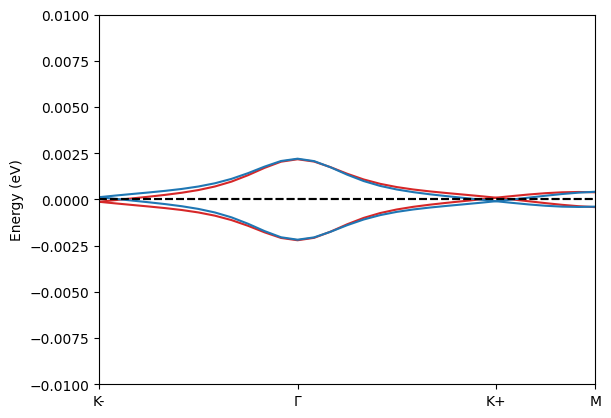

In [17]:
plot_band(model.e[0],Erange=0.01, c='tab:red') # +
plot_band(model.e[1],Erange=0.01, c='tab:blue') # -
plt.xticks(xtp,xtk)
plt.show()
# plt.ticklabel_format(axis="y",style="sci",scilimits=(0,0),useMathText=True)

In [18]:
model.init_mesh(12)
model.calculate_bandstructure()
calculate_mu(model, occ=0, T=0.4)

In [19]:
chi_ph_q = model.calculate_chi_ph_q()
chi_pp_q = model.calculate_chi_pp_q()

In [26]:
model.chi_ph_q.shape

(2, 2, 49, 49)

In [43]:
import time

chi_k = []
time_cost = []

for k in np.arange(6,60,6):
    start = time.perf_counter()

    model.init_mesh(k)
    model.calculate_bandstructure()
    calculate_mu(model, occ=0, T=4.2)
    chi_q = model.calculate_chi_q()

    time_cost.append(time.perf_counter() - start)
    chi_k.append(chi_q)


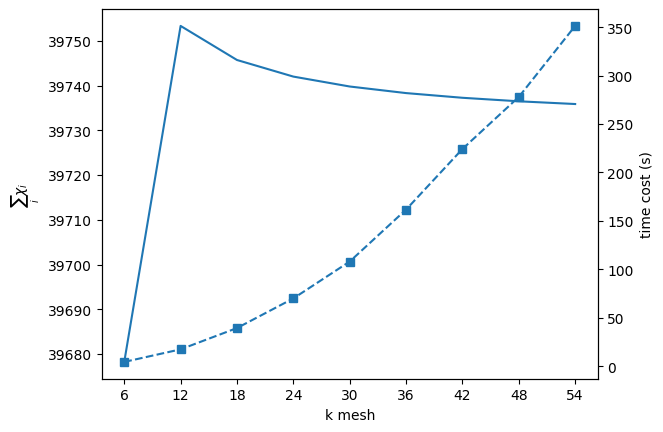

In [44]:
plt.plot(np.arange(6,60,6), [np.sum(chi_i).real for chi_i in chi_k], label=r"$\sum_i \chi_i$")
plt.xlabel("k mesh")
plt.ylabel(r"$\sum_i \chi_i$")
plt.xticks(np.arange(6,60,6), np.arange(6,60,6))

plt.twinx()
plt.plot(np.arange(6,60,6), time_cost, "s--", label="time cost")
plt.ylabel("time cost (s)")

plt.show()

### particle-hole channel

In [35]:
def cal_rpa(chi, Umat, channel='charge', basis='spinless'):
    # U_4 = tensor(U, J)
    # Uc, Us = split_quartic_tensor_in_charge_and_spin(U_4)

    # Umat = Uc if channel == 'charge' else Us
    # Umat = Umat.transpose((0, 1, 3, 2)).reshape(4, 4)

    if basis == 'spinless':
        rpa = chi @ Umat

    elif basis == 'pseudospin':
        lead = chi.shape[:-4]
        ng = chi.shape[-1]
        block = chi.reshape(lead + (4, ng, ng))
        chi_big = np.zeros(
            lead + (4, ng, 4, ng),
            dtype=chi.dtype
        )

        for p in range(4):
            chi_big[..., p, :, p, :] = block[..., p, :, :]

        chi_big = chi_big.reshape(lead + (4 * ng, 4 * ng))
        U_big = np.kron(Umat, np.eye(ng))
        rpa = chi_big @ U_big

    else:
        raise KeyError("basis must be 'spinless' or 'pseudospin'")

    return rpa

In [36]:
def rpa_phase(rpa, tol=1e-12): 
    # sx = np.array([[0,1],[1,0]],dtype=complex)
    # sz = np.array([[1,0],[0,-1]],dtype=complex)
    # sx/=np.linalg.norm(sx)
    # sz/=np.linalg.norm(sz)
    # rpa = rpa.reshape((ix,iy,2,2,2,2)).transpose((0,1,2,3,5,4))
    # ivc = np.einsum('ab,xyabcd,dc->xy', sx,rpa,sx)
    # stoner = np.einsum('ab,xyabcd,dc->xy', sz,rpa,sz)
    # return ivc, stoner

    lead = rpa.shape[:-2]
    dim = rpa.shape[-1]

    if dim % 4 != 0:
        raise ValueError("Last dimension of rpa must be 4*ng.")

    ng = dim // 4

    vl, vc = np.linalg.eig(rpa)

    args = np.argmax(vl.real, axis=-1)
    lam = np.take_along_axis(vl.real, args[..., None], axis=-1)[..., 0]

    vec = np.take_along_axis(vc, args[..., None, None], axis=-1)[..., 0]
    vec = vec.reshape(lead + (2, 2, ng))

    v00 = vec[..., 0, 0, :]
    v11 = vec[..., 1, 1, :]
    v01 = vec[..., 0, 1, :]
    v10 = vec[..., 1, 0, :]

    w_charge = np.sum(np.abs(v00 + v11)**2, axis=-1)
    w_stoner = np.sum(np.abs(v00 - v11)**2, axis=-1)
    w_ivc    = np.sum(np.abs(v01)**2 + np.abs(v10)**2, axis=-1)

    phase = np.where(
        lam < 1 - tol,
        0,
        np.where(w_stoner > w_ivc, 1, 2)
    )

    return phase #, lam, w_charge, w_stoner, w_ivc

1.3523581515877336 0.9257051660756941


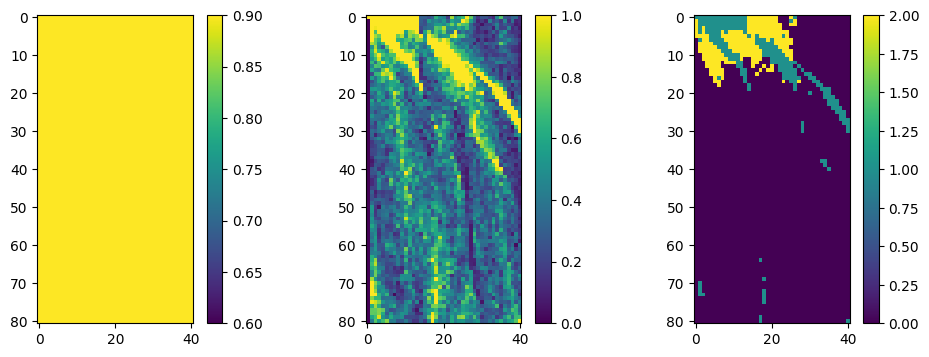

In [95]:
plt.figure(figsize=(12,4))

ix, iy, _, _ = chi.shape # (41,81,4,4)
rpa = cal_rpa(chi, U=0.0045, J=0, basis='spinless')
lc_ivc, lc_stoner = rpa_phase(rpa)

plt.subplot(1,3,1)
plt.imshow(lc_ivc.T.real,vmax=0.9,vmin=0.6)
plt.colorbar()
print(lc_ivc.T.real.max(),lc_ivc.T.real.min())

plt.subplot(1,3,2)
plt.imshow(lc_stoner.T.real,vmax=1,vmin=0)
plt.colorbar()

plt.subplot(1,3,3)
lambdas = np.stack([np.ones((ix,iy)),lc_stoner,lc_ivc])
phase_map = np.argmax(lambdas,axis=0)
plt.imshow(phase_map.T)
plt.colorbar()

In [20]:
model = RhombohedralMultilayer(V=30,Qcut=3,nlayer=2,theta=1.08)
model.V00()

0.002440000000000001

In [38]:
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(["white", "tab:blue", "tab:red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

In [56]:
data = np.load("pp_theta.npz")
chi_ph = data["chi_ph_map"]
chi_pp = data["chi_pp_map"]
chi_ph.shape

(51, 81, 2, 2, 2, 2)

In [57]:
def ph_matrix(A):
    # Same convention as:
    # A.transpose(2,0,1,3).reshape(4,4)
    # but with leading (x,y) axes.
    x, y = A.shape[:2]
    return A.transpose(0, 1, 2, 3, 5, 4).reshape(x, y, 4, 4)

chi0_ph = ph_matrix(chi_ph)
chi0_ph.shape

(51, 81, 4, 4)

 89%|████████▉ | 8/9 [00:00<00:00, 15.12it/s]


[Text(1, 0, 'FL'), Text(1, 1, 'Stoner'), Text(1, 2, 'IVC')]

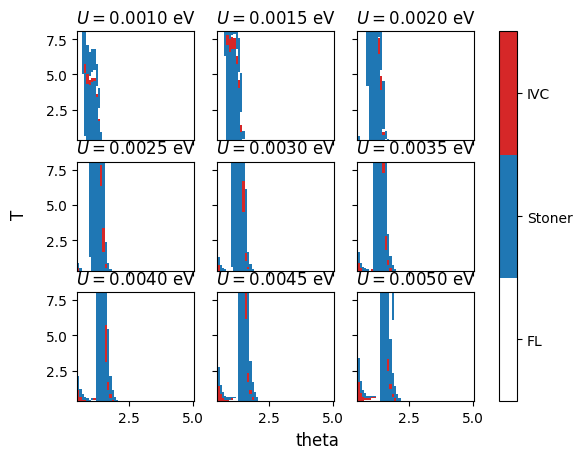

In [58]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)

Us = np.linspace(0.001, 0.0050, 9)

for ax, U in zip(axs.flat, tqdm(Us)):
    out = vertex(tensor1(U,U/10), chi_ph=chi_ph, chi_pp=chi_pp)
    rpa = cal_rpa(chi0_ph, Umat=out['V_d'], basis='spinless')
    phase = rpa_phase(rpa)

    im = ax.pcolormesh(
        data["x_grid"],
        data["y_grid"],
        # occ,disp,
        np.asarray(phase).T,
        cmap=cmap,
        vmin=-0.5,
        vmax=2.5,
    )

    ax.set_title(rf"$U={U:.4f}$ eV")

fig.supxlabel(data["x_name"])
fig.supylabel(data["y_name"])

cbar = fig.colorbar(im, ax=axs, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["FL", "Stoner", "IVC"])

# plt.xlabel(r'dopping $n_e (10^{12} cm^{-2})$')
# plt.xlabel(r'twist angle ($\theta$)')
# plt.ylabel('displacement field (meV)')

A real on-site Hubbard interaction is
$$
U n_{\uparrow} n_{\downarrow}.
$$
It acts between **opposite spins** on the same site. If you remove spin, then the local same-orbital interaction is strongly constrained by Pauli exclusion:
$$
n^2 = n.
$$
So a purely spinless local Hubbard model does **not** have the same interaction structure as the physical spinful Hubbard model.

That matters because IVC usually needs a transverse valley-exchange channel:
$$
\rho_{+-} = c^\dagger_+ c_-.
$$
This is an intervalley coherence channel. In graphene, intervalley coherence involves large momentum transfer between $K$ and $K'$. Long-range Coulomb mainly couples total density and usually does not strongly enhance this channel. The short-range interaction that can support intervalley exchange is exactly the part most sensitive to spin and microscopic orbital structure.

### particle-particle channel

In [29]:
def vertex(U_4, chi_ph=None, chi_pp=None):
    U_4 = -U_4
    # U_4 = tensor(U, V)
    # print(U_4)

    perm = lambda T, p: T.transpose(
        *range(T.ndim - len(p)),
        *(T.ndim - len(p) + i for i in p)
    )

    U4_to_8 = lambda T: perm(
        T.reshape(*T.shape[:-4], 2,2,2,2,2,2,2,2),
        (0,2,4,6,1,3,5,7)
    )

    ph_t2m = lambda T: perm(T, (0,1,3,2)).reshape(*T.shape[:-4], 16, 16)
    ph_m2t = lambda M: perm(M.reshape(*M.shape[:-2], 4,4,4,4), (0,1,3,2))

    pp_t2m = lambda T: perm(T, (2,0,1,3)).reshape(*T.shape[:-4], 16, 16)
    pp_m2t = lambda M: perm(M.reshape(*M.shape[:-2], 4,4,4,4), (1,2,0,3))

    ph4_t2m = lambda T: perm(T, (0,1,3,2)).reshape(*T.shape[:-4], 4, 4)
    pp4_t2m = lambda T: perm(T, (2,0,1,3)).reshape(*T.shape[:-4], 4, 4)

    def embed_chi(chi):
        chi = np.asarray(chi)
        chi8 = np.zeros((*chi.shape[:-4], 2,2,2,2,2,2,2,2), dtype=chi.dtype)

        for s in range(2):
            chi8[..., s, s, s, s, :, :, :, :] = chi
            chi8[..., s, 1-s, 1-s, s, :, :, :, :] = chi

        return perm(chi8, (0,4,1,5,2,6,3,7)).reshape(*chi.shape[:-4], 4,4,4,4)

    U_8 = U4_to_8(U_4)

    U_d = U_8[0,0,0,0] + U_8[0,0,1,1]
    U_m = U_8[0,0,0,0] - U_8[0,0,1,1]
    U_s = U_8[0,0,1,1] - U_8[0,1,1,0]
    U_t = U_8[0,0,1,1] + U_8[0,1,1,0]

    out = {
        "U_d": ph4_t2m(U_d),
        "U_m": -ph4_t2m(U_m),
        "U_s": pp4_t2m(U_s),
        "U_t": pp4_t2m(U_t),
    }

    if chi_ph is None and chi_pp is None:
        return out

    U_ph = ph_t2m(U_4)
    U_pp = pp_t2m(U_4)
    I = np.eye(16)

    chi_ph_mat = ph_t2m(embed_chi(chi_ph))
    Phi_ph = ph_m2t(
        np.linalg.solve(I - U_ph @ chi_ph_mat, U_ph) - U_ph
    )

    vPhi_ph = -perm(Phi_ph, (2,1,0,3))

    chi_pp_mat = pp_t2m(embed_chi(chi_pp))
    Phi_pp = pp_m2t(
        np.linalg.solve(I - 0.5 * U_pp @ chi_pp_mat, U_pp) - U_pp
    )

    V8_pair = U4_to_8(U_4 + Phi_ph + vPhi_ph)

    Vs4 = V8_pair[...,0,0,1,1,:,:,:,:] - V8_pair[...,0,1,1,0,:,:,:,:]
    Vt4 = V8_pair[...,0,0,1,1,:,:,:,:] + V8_pair[...,0,1,1,0,:,:,:,:]

    V8_ph = U4_to_8(U_4 + Phi_pp + vPhi_ph)

    Vd4 = V8_ph[...,0,0,0,0,:,:,:,:] + V8_ph[...,0,0,1,1,:,:,:,:]
    Vm4 = V8_ph[...,0,0,0,0,:,:,:,:] - V8_ph[...,0,0,1,1,:,:,:,:]

    out.update({
        "V_d": ph4_t2m(Vd4),
        "V_m": -ph4_t2m(Vm4),
        "V_s": pp4_t2m(Vs4),
        "V_t": pp4_t2m(Vt4),
    })

    return out

#### Bethe-Salpeter equation

The Bethe--Salpeter equation is basically the general equation for a two-particle vertex or susceptibility. In compact form,
$$
F = \Gamma + \Gamma \chi F.
$$
Solving gives
$$
F = (1-\Gamma\chi)^{-1}\Gamma.
$$


In [30]:
def tensor1(U, V):
    # index order: 0=up0, 1=up1, 2=dn0, 3=dn1
    U4 = np.zeros((4, 4, 4, 4), dtype=float)

    def add_density_pair(p, q, x):
        U4[p, q, q, p] += x
        U4[q, p, p, q] += x
        U4[p, p, q, q] -= x
        U4[q, q, p, p] -= x

    # H0 = n_up0 n_dn0 + n_up1 n_dn1
    add_density_pair(0, 2, U)
    add_density_pair(1, 3, U)

    # H1 = (n_up0+n_dn0)(n_up1+n_dn1)
    add_density_pair(0, 1, V)
    add_density_pair(0, 3, V)
    add_density_pair(2, 1, V)
    add_density_pair(2, 3, V)

    return U4

In [26]:
def tensor2(U, V):
    U4 = np.zeros((4, 4, 4, 4), dtype=float)

    def add_density_pair(p, q, x):
        U4[p, q, q, p] += x
        U4[q, p, p, q] += x
        U4[p, p, q, q] -= x
        U4[q, q, p, p] -= x

    g = U + V

    for p in range(4):
        for q in range(p + 1, 4):
            add_density_pair(p, q, g)

    return U4

In [61]:
def pp_phase_diagram(chi_pp, Vs, Vt, tol=1e-3):

    def pp_matrix(A):
        # Same convention as:
        # A.transpose(2,0,1,3).reshape(4,4)
        # but with leading (x,y) axes.
        x, y = A.shape[:2]
        return A.transpose(0, 1, 4, 2, 3, 5).reshape(x, y, 4, 4)

    chi = pp_matrix(chi_pp)
    # Vs = pp_matrix(V_s)
    # Vt = pp_matrix(V_t)

    Ks = (Vs @ chi)
    Kt = (Vt @ chi)

    x, y = chi.shape[:2]
    phase = np.zeros((x, y), dtype=int)

    for i in range(x):
        for j in range(y):

            # singlet
            ws, vecs = np.linalg.eig(Ks[i, j])
            ids = np.argmax(ws.real)
            lam_s = ws[ids].real
            vec_s = vecs[:, ids]
            # print(lam_s)

            # triplet
            wt, vect = np.linalg.eig(Kt[i, j])
            idt = np.argmax(wt.real)
            lam_t = wt[idt].real
            vec_t = vect[:, idt]
            # print(lam_t)

            # pick dominant spin channel
            if lam_s >= lam_t:
                lam = lam_s
                vec = vec_s
                spin = "singlet"
            else:
                lam = lam_t
                vec = vec_t
                spin = "triplet"

            # normal if no pp instability
            if lam < 1 - tol:
                phase[i, j] = 0
                continue

            # classify Cooper vs PDW from eigenvector weight
            w_pdw = abs(vec[0])**2 + abs(vec[3])**2       # (00), (11)
            w_cooper = abs(vec[1])**2 + abs(vec[2])**2    # (01), (10)

            if spin == "singlet":
                phase[i, j] = 3 if w_pdw > w_cooper else 1
            else:
                phase[i, j] = 4 if w_pdw > w_cooper else 2

    return phase

In [64]:
labels = [
    "normal",
    "s-Cooper",
    "t-Cooper",
    "s-PDW",
    "t-PDW",
]

cmap = ListedColormap([
    "white",
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
])

bounds = np.arange(len(labels) + 1) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

data = np.load("pp_theta.npz")
chi_ph = data["chi_ph_map"]
chi_pp = data["chi_pp_map"]
chi_ph.shape

(51, 81, 2, 2, 2, 2)

 89%|████████▉ | 8/9 [00:01<00:00,  5.52it/s]


[Text(1, 0, 'normal'),
 Text(1, 1, 's-Cooper'),
 Text(1, 2, 't-Cooper'),
 Text(1, 3, 's-PDW'),
 Text(1, 4, 't-PDW')]

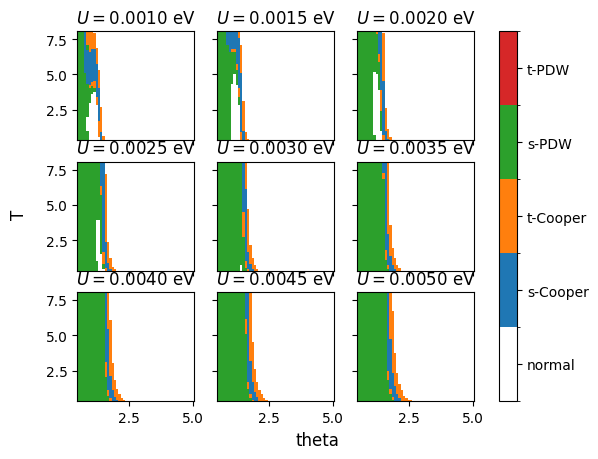

In [65]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)

Us = np.linspace(0.001, 0.005, 9)

for ax, U in zip(axs.flat, tqdm(Us)):
    out = vertex(tensor1(U, U/10), chi_ph=chi_ph, chi_pp=chi_pp)
    phase = pp_phase_diagram(chi_pp, Vs=out["V_s"], Vt=out["V_t"])
    
    im = ax.pcolormesh(
        data["x_grid"],
        data["y_grid"],
        np.asarray(phase).T,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.set_title(rf"$U={U:.4f}$ eV")

fig.supxlabel(data["x_name"])
fig.supylabel(data["y_name"])

cbar = fig.colorbar(
    im,
    ax=axs,
    ticks=np.arange(len(labels)),
    boundaries=bounds,
    spacing="uniform",
)

cbar.ax.set_yticklabels(labels)

### TRG band and Chern number

In [282]:
def plot_bs(km,theta,nlayer,valley=[-1,1],E_field=0.0,sub_pot=[0,0],disorder=np.zeros((2,2)),Er=None,sparse=False,bar=1):
    bar = tqdm if bar else np.array
    EF = 0
    c = {1:'r',-1:'b'}
    th = np.deg2rad(theta)
    for _v in valley:
        if sparse:
            from scipy.sparse.linalg import eigsh 
        eigval_k = []
    
        for k in bar(km):
            Hk = get_hk(k,_v,th,nlayer,E_field,sub_pot,disorder)
            if sparse:
                eigval,_ = eigsh(Hk,16,sigma=1e-6)
            else:
                eigval,_ = np.linalg.eigh(Hk)
            eigval_k.append(eigval)
        eigval_k = np.array(eigval_k)
    
        all_eigval = np.sort(eigval_k.flatten())
        EF += all_eigval[eigval_k.shape[-1]*km.shape[0]//2+_v]
        for band in eigval_k.T:
            if sparse:
                plt.scatter(range(len(km)),band,c=f'{c[_v]}')
            else:
                plt.plot(range(len(km)),band,f'{c[_v]}-')
                
    plt.axhline(EF/len(valley), color='k', linestyle='--', lw=0.8)
    plt.xticks(xtp,xtk)
    plt.tight_layout()
    plt.xlim(0,km.shape[0]-1)
    plt.title(f'θ = {theta:.2f}')
    if Er:
        plt.ylim(EF/len(valley)-Er,EF/len(valley)+Er)
    for p in xtp:
        plt.axvline(p,color='k',linestyle='--',lw=0.5)
    # plt.show()
    return EF/len(valley)

In [14]:
def plot_bc(theta,nlayer,valley=1,n=100,idx=[1,1],E_field=0.0,sub_pot=[0,0],disorder=np.zeros((2,2))):
    from numpy.linalg import det as det
    from scipy.linalg import eigh
    th = np.deg2rad(theta)

    kn = np.linspace(0,1,n)
    x,y = np.meshgrid(kn,kn)
    
    BC = np.zeros((n-1,n-1))
    vecs = np.zeros((n,n,Ndim,idx[1]-idx[0]+1),dtype=complex)

    for i in tqdm(range(n)):
        for j in range(n):
            Hk = get_hk([x[i,j],y[i,j]],valley,th,nlayer,E_field,sub_pot,disorder)
            val, vec = eigh(Hk, subset_by_index=idx)
            vecs[i,j] = vec

    for i in range(n-1):
        for j in range(n-1):
            line1 = vecs[i,j].conj().T@vecs[i+1,j]
            line2 = vecs[i+1,j].conj().T@vecs[i+1,j+1]
            line3 = vecs[i+1,j+1].conj().T@vecs[i,j+1]
            line4 = vecs[i,j+1].conj().T@vecs[i,j]
            phi = -np.angle(det(line1)*det(line2)*det(line3)*det(line4))
            BC[i,j] = phi
    
    C = np.sum(BC)/2/np.pi

    b1 = np.array([-0.5, -np.sqrt(3)/2])
    b2 = np.array([ 1.0,  0.0         ])
    _k = np.linspace(-1,1,2*n-2,endpoint=False)
    _x,_y = np.meshgrid(_k,_k)
    X = _x * b1[0] + _y * b2[0]
    Y = _x * b1[1] + _y * b2[1]

    corners = np.array([
        (2*b1 +   b2)/3,
        (  b1 + 2*b2)/3,
        (- b1 +   b2)/3,
        (-2*b1-   b2)/3,
        (- b1 - 2*b2)/3,
        (  b1 -   b2)/3,
        (2*b1 +   b2)/3,
    ])

    idx = idx[0] if idx[0] == idx[1] else idx

    plt.pcolormesh(X,Y,np.tile(BC.T,(2,2)),cmap='bwr')
    plt.title(fr'$\theta=${theta:.2f}°,K={valley},idx={idx}, $C=${C:.2f}')
    plt.plot(corners[:,0],corners[:,1],'k-')
    plt.xlabel('kx');plt.ylabel('ky')
    plt.xticks([]);plt.yticks([])
    plt.axis('scaled')
    plt.colorbar()
    
    _f = 2/3
    plt.ylim(-b2[0]*_f,b2[0]*_f)
    plt.xlim(-b1[1]*_f,b1[1]*_f)
    
    return C

In [15]:
def compare_bc(E_field=0,sub_pot=[0,0],disorder=np.zeros((2,2)),n=51):
    fig = plt.figure(figsize=(12,8))
    plt.subplot(2,2,1)
    plot_bc(theta,nlayer,1,n,[Ndim//2,Ndim//2],E_field,sub_pot,disorder)
    plt.subplot(2,2,2)
    plot_bc(theta,nlayer,-1,n,[Ndim//2,Ndim//2],E_field,sub_pot,disorder)
    plt.subplot(2,2,3)
    plot_bc(theta,nlayer,1,n,[Ndim//2-1,Ndim//2-1],E_field,sub_pot,disorder)
    plt.subplot(2,2,4)
    plot_bc(theta,nlayer,-1,n,[Ndim//2-1,Ndim//2-1],E_field,sub_pot,disorder)

#### tbg benchmark

In [16]:
u_AA = 0.070 # eV
u_AB = 0.110 # eV
vppsigma = 0.40 # eV
vf = 5.817
Qcut = 3

In [17]:
kpt = np.array([
    [ 2/3, 1/3, 0  ], # K-
    [ 0  , 0  , 0  ], # Γ
    [ 1/3, 2/3, 0  ], # K+
    [ 0  , 1/2, 0  ], # M
])

xtk = ['K-','Γ','K+','M']
km, xtp = gen_kpath(kpt, 51, return_ticks_points=True)

In [19]:
nlayer = 8
Ndim = ((2*Qcut+1)**2)*2*nlayer

np.float64(1.4313185199414016e-10)

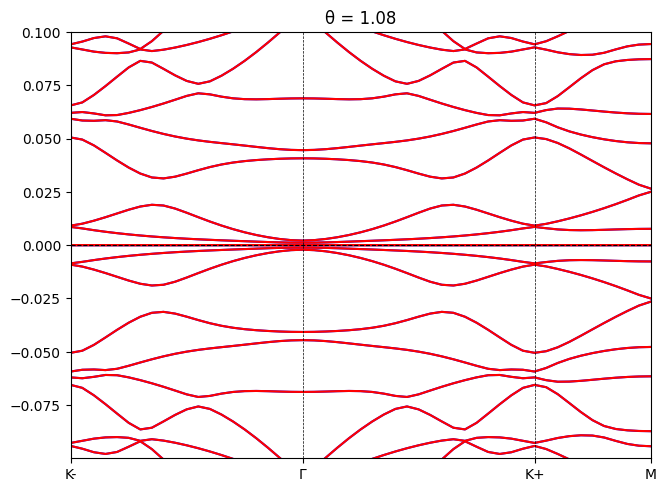

In [20]:
plot_bs(km,theta=1.08,nlayer=nlayer,bar=0, Er=0.1)

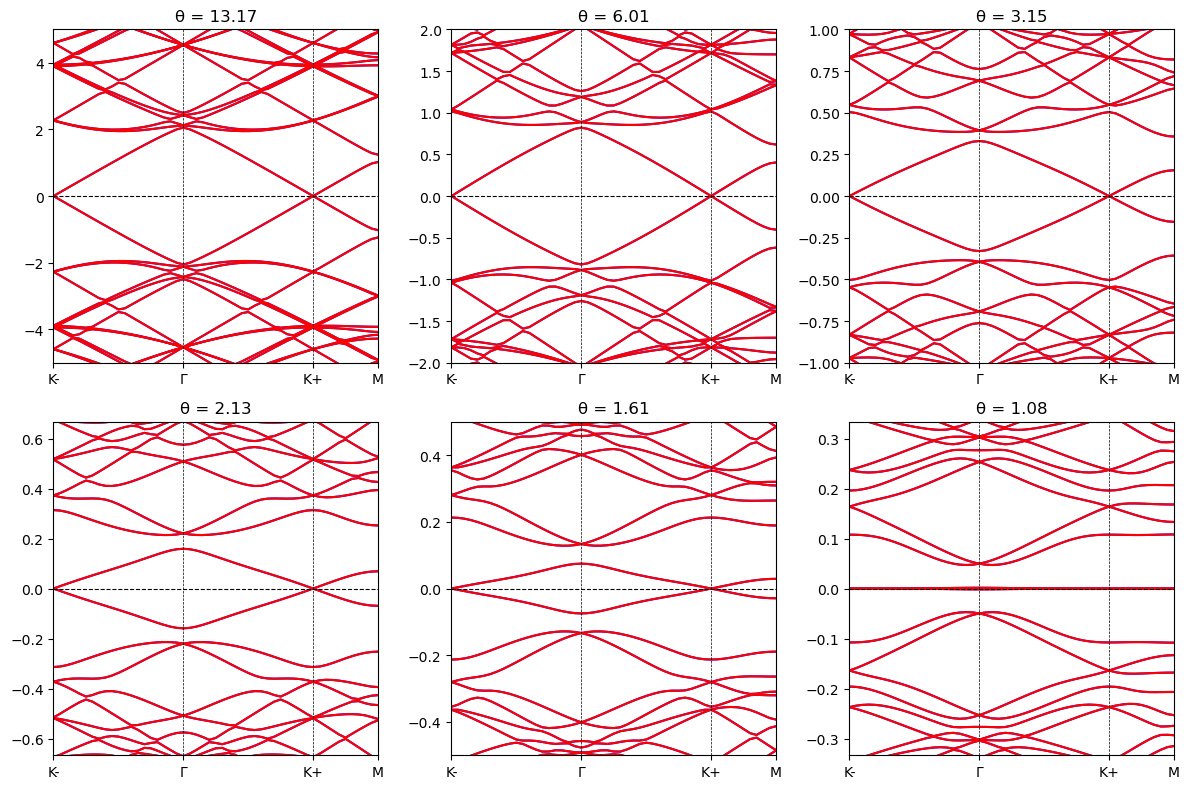

In [18]:
fig = plt.figure(figsize=(12,8))
for i,m in enumerate([2,5,10,15,20,30]):
    theta = f_theta(m)
    plt.subplot(2,3,i+1)
    plot_bs(km,theta,nlayer,Er=10/m,bar=0)

In [19]:
u_AA = 0.0797 # eV
u_AB = 0.0975 # eV
vppsigma = 0.30 # eV
vf = 2.1354*a
Qcut = 3

In [20]:
nlayer = 2; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [00:00<00:00, 200.67it/s]


-0.0005525436942148476

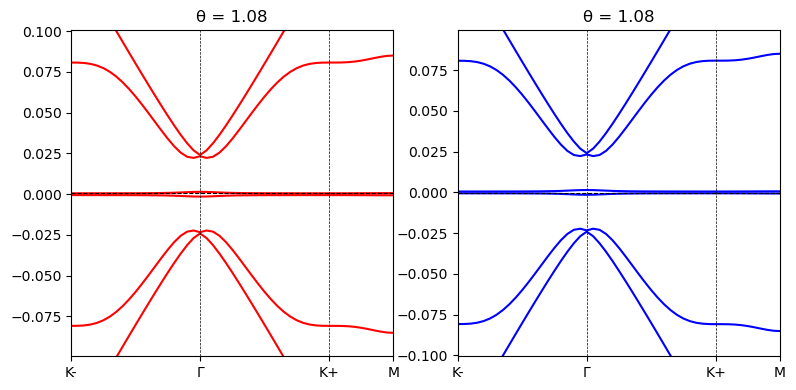

In [21]:
fig = plt.figure(figsize=(8,4))
sub_pot=[0.002,-0.002]
plt.subplot(1,2,1)
plot_bs(km,theta,nlayer,Er=0.1,valley=[1],sub_pot=sub_pot)
plt.subplot(1,2,2)
plot_bs(km,theta,nlayer,Er=0.1,valley=[-1],sub_pot=sub_pot)

100%|██████████| 31/31 [00:04<00:00,  7.70it/s]


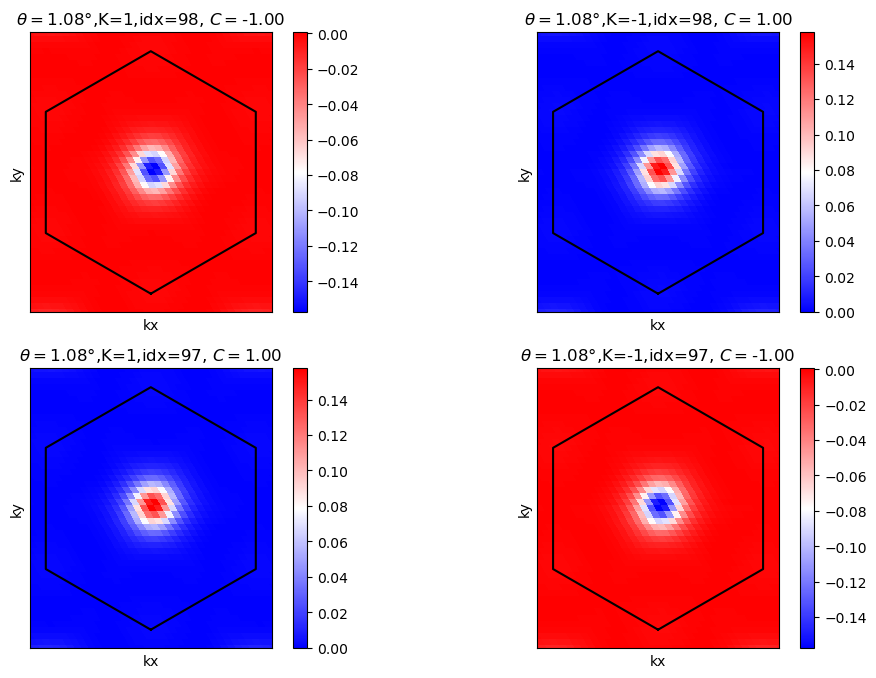

In [22]:
compare_bc(sub_pot=sub_pot,n=31)

#### 4-layers TDBG

In [23]:
nlayer = 4; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [00:00<00:00, 60.94it/s]


0.004951039274676358

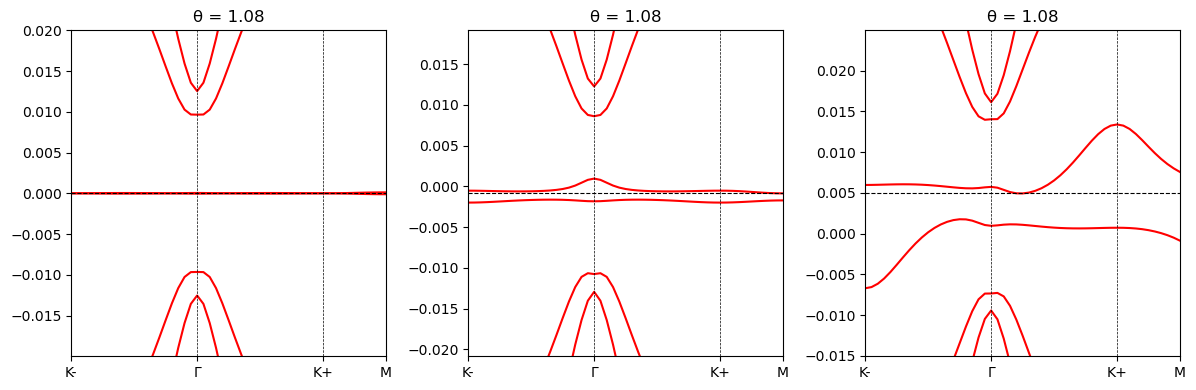

In [24]:
fig = plt.figure(figsize=(12,4))
sub_pot=[0.002,-0.002]
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=0.02,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=0.02,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=0.02,valley=[1],E_field=2e-3)

100%|██████████| 31/31 [00:11<00:00,  2.65it/s]


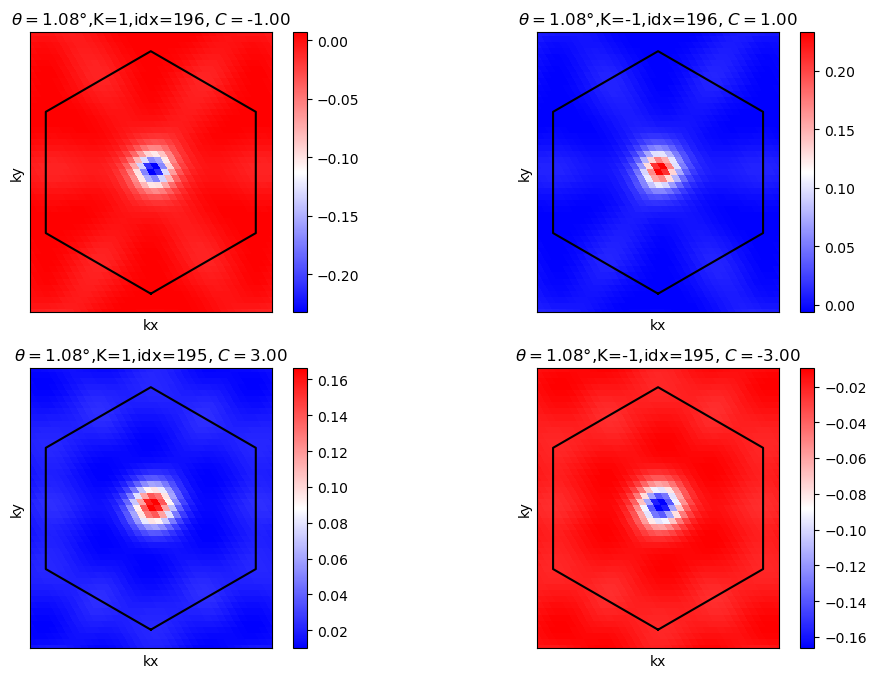

In [25]:
compare_bc(sub_pot=sub_pot,n=31)

100%|██████████| 31/31 [00:12<00:00,  2.58it/s]


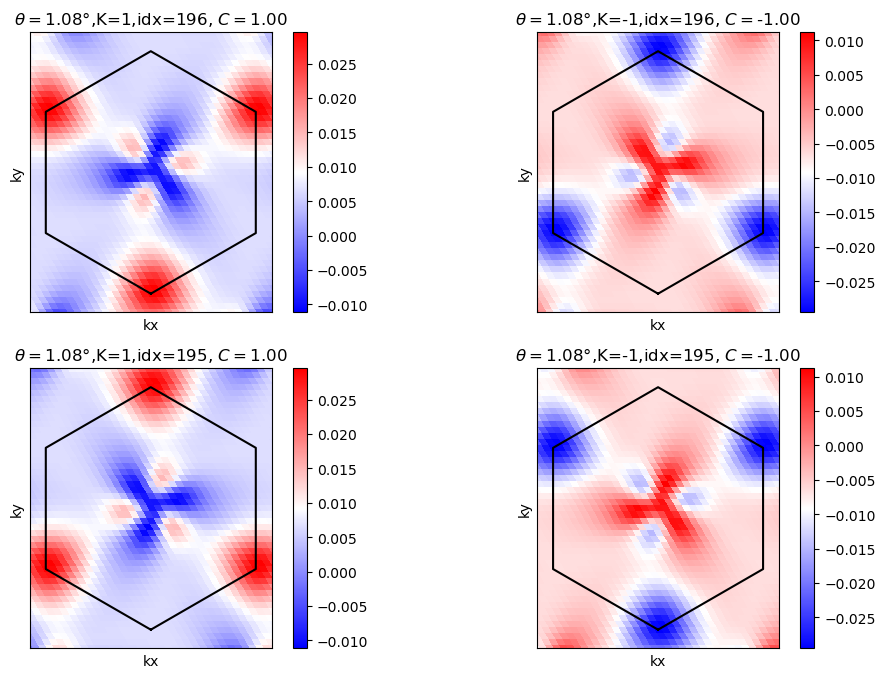

In [27]:
compare_bc(E_field=2e-3,n=31)

#### 6-layers (ABC-CBA)

In [69]:
nlayer = 6; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [00:01<00:00, 37.40it/s]


0.001244052968322416

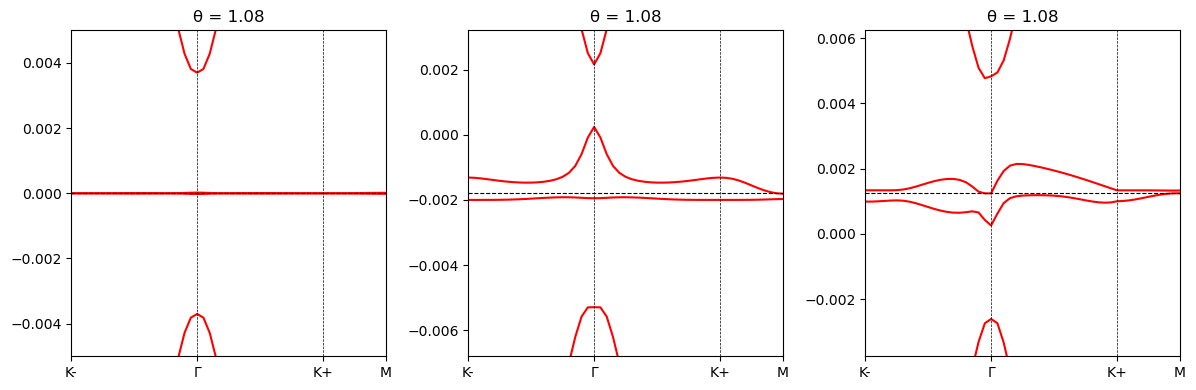

In [70]:
fig = plt.figure(figsize=(12,4))
sub_pot=[2e-3,-2e-3]
disorder = np.random.uniform(-2e-3,2e-3,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 51/51 [00:01<00:00, 30.04it/s]


0.016680855813542023

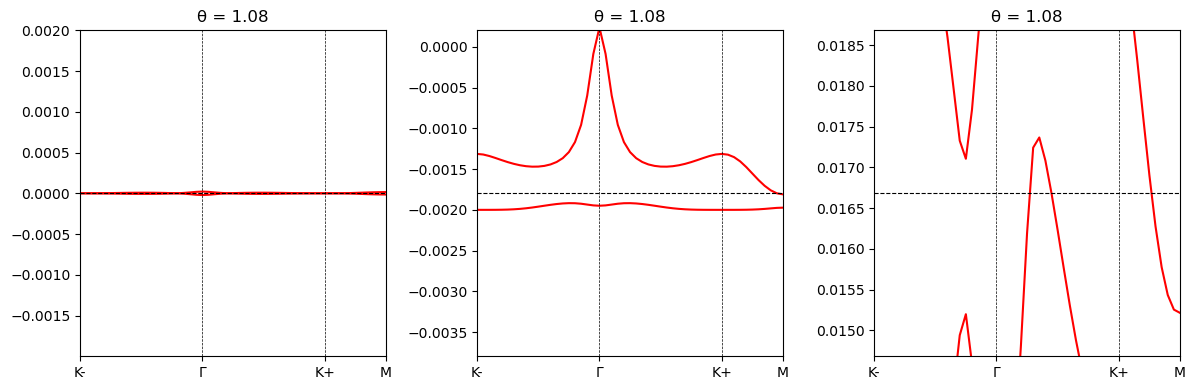

In [35]:
fig = plt.figure(figsize=(12,4))
sub_pot=[2e-3,-2e-3]
disorder = np.random.uniform(1.5e-2,2.5e-2,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=0.002,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=0.002,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=0.002,valley=[1],disorder=disorder)

100%|██████████| 100/100 [03:34<00:00,  2.14s/it]


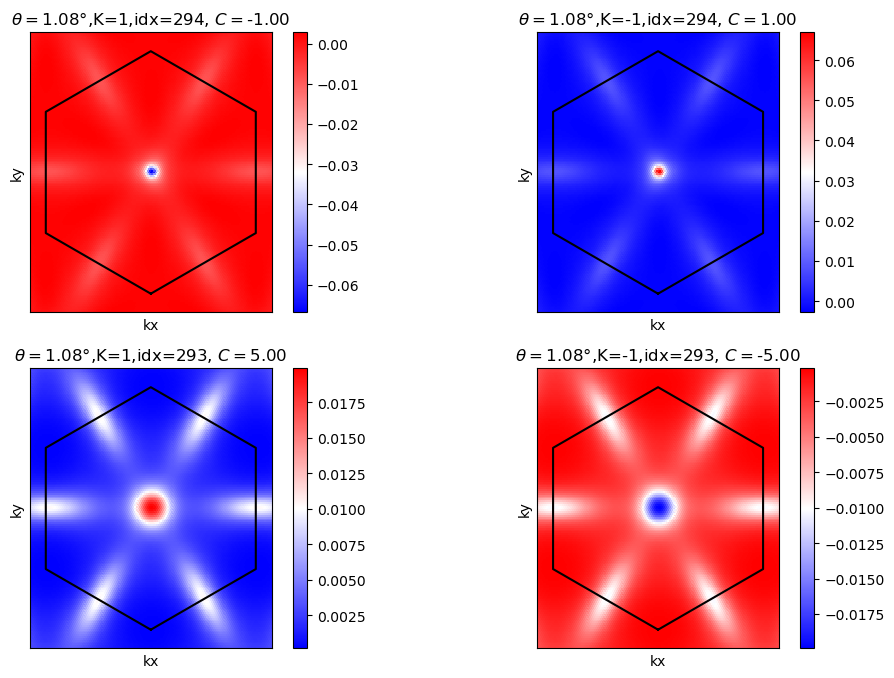

In [31]:
compare_bc(pot=sub_pot,n=100)

100%|██████████| 31/31 [00:37<00:00,  1.20s/it]


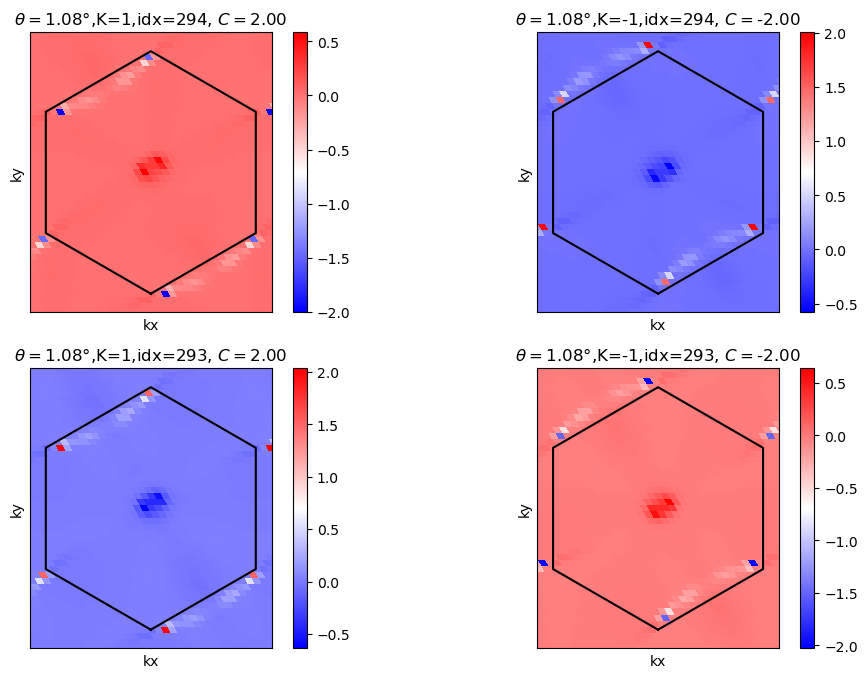

In [95]:
compare_bc(disorder=disorder,n=31)

100%|██████████| 31/31 [00:21<00:00,  1.46it/s]


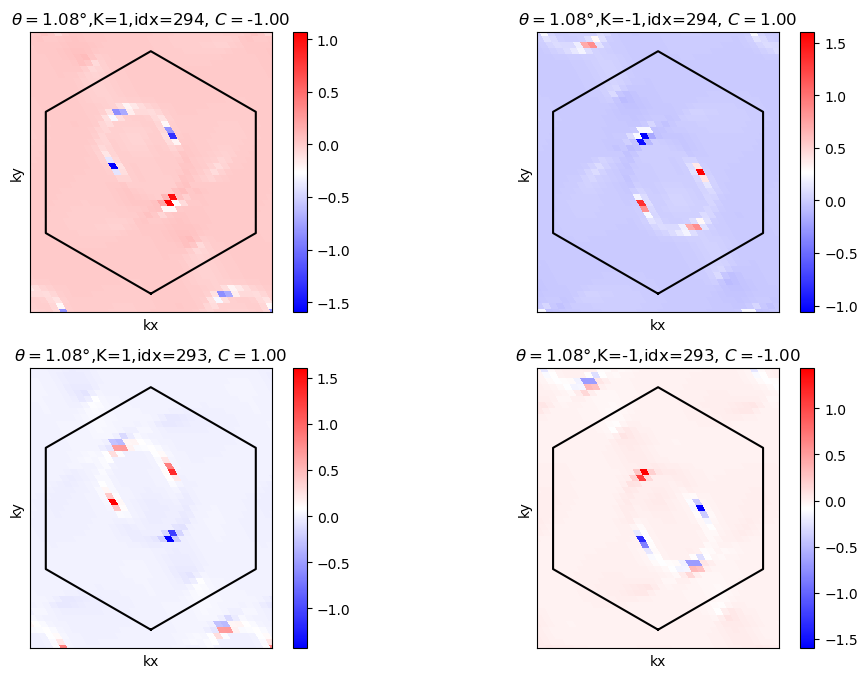

In [36]:
compare_bc(disorder=disorder,n=31)

#### 12-layers (ABC-CBA)

In [71]:
nlayer = 12; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [00:09<00:00,  5.25it/s]


0.0016388511883447317

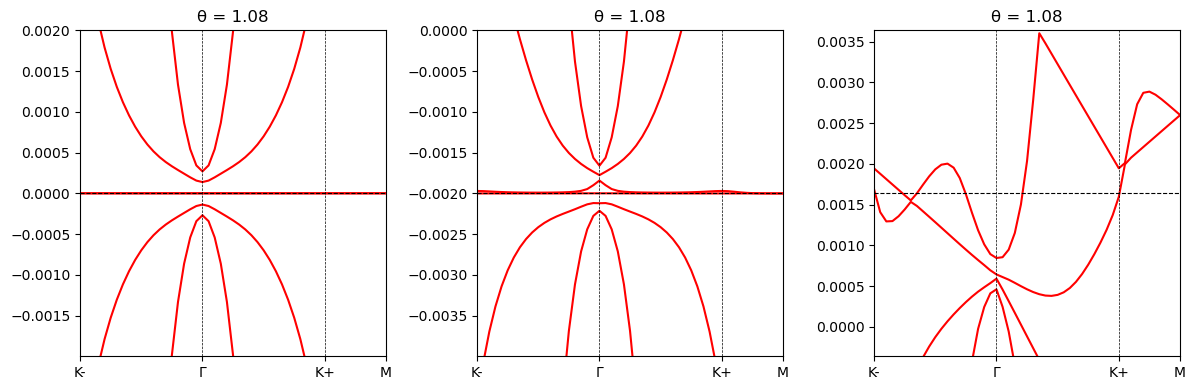

In [72]:
fig = plt.figure(figsize=(12,4))
s = 2e-3
sub_pot=[s,-s]
disorder = np.random.uniform(-s,s,(2,2))+1j*np.random.uniform(-s,s,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=s,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=s,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=s,valley=[1],disorder=disorder)

100%|██████████| 51/51 [00:09<00:00,  5.62it/s]


-0.0015847122116882145

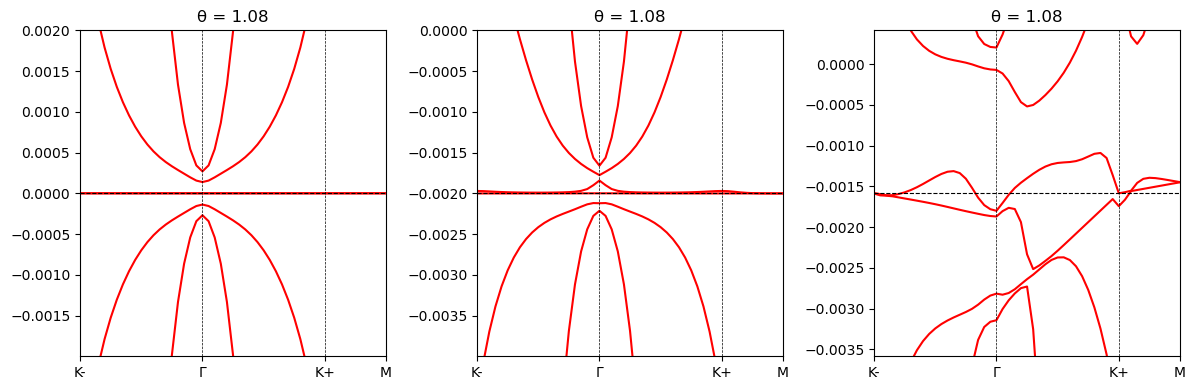

In [73]:
fig = plt.figure(figsize=(12,4))
s = 2e-3
sub_pot=[s,-s]
disorder = np.random.uniform(-s,s,(2,2))+1j*np.random.uniform(-s,s,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=s,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=s,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=s,valley=[1],disorder=disorder)

100%|██████████| 51/51 [00:08<00:00,  5.73it/s]


0.00034955676808364004

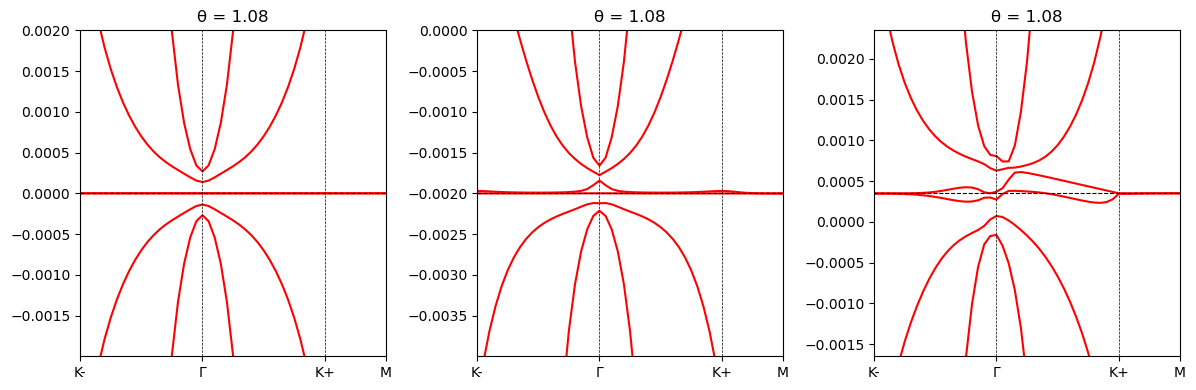

In [74]:
fig = plt.figure(figsize=(12,4))
s = 2e-3
sub_pot=[s,-s]
disorder = np.random.uniform(-s,s,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=s,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=s,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=s,valley=[1],disorder=disorder)

100%|██████████| 31/31 [01:31<00:00,  2.96s/it]


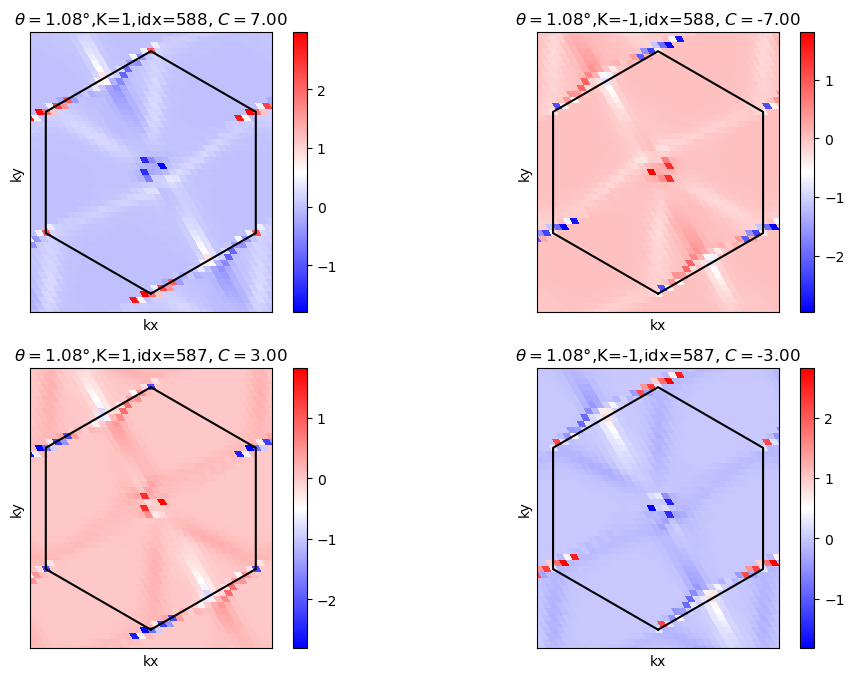

In [75]:
compare_bc(disorder=disorder,n=31)

100%|██████████| 31/31 [00:20<00:00,  1.50it/s]


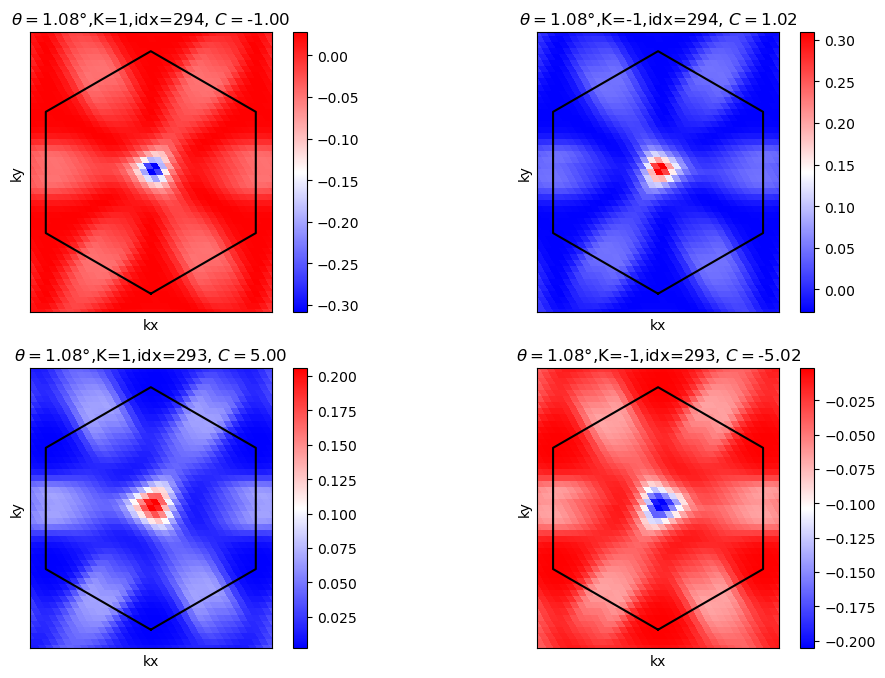

In [27]:
compare_bc(sub_pot=sub_pot,n=31)

#### 24-layers (ABC-CBA)

In [23]:
nlayer = 24; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [01:12<00:00,  1.42s/it]


1.3875928256869432e-07

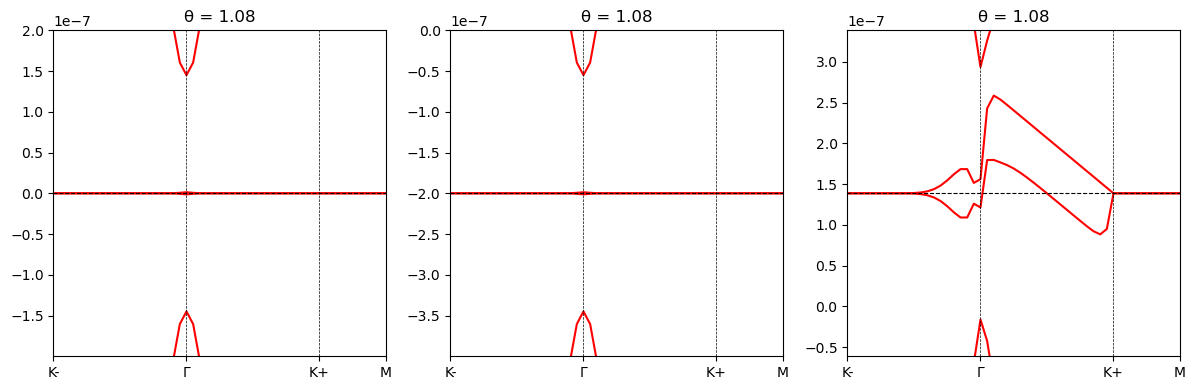

In [24]:
fig = plt.figure(figsize=(12,4))
s = 2e-7
sub_pot=[s,-s]
disorder = np.random.uniform(-s,s,(2,2))
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=s,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=s,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=s,valley=[1],disorder=disorder)

100%|██████████| 25/25 [09:31<00:00, 22.86s/it]


22.000037009442742

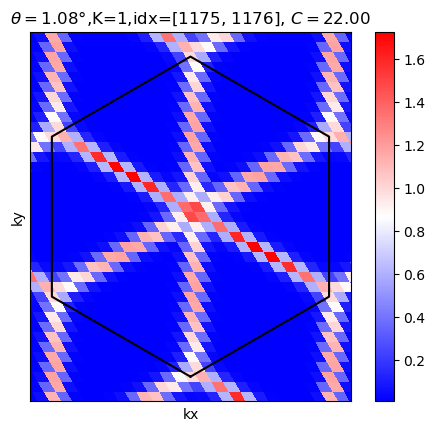

In [25]:
plot_bc(theta,nlayer,1,25,[Ndim//2-1,Ndim//2])

100%|██████████| 19/19 [05:38<00:00, 17.79s/it]


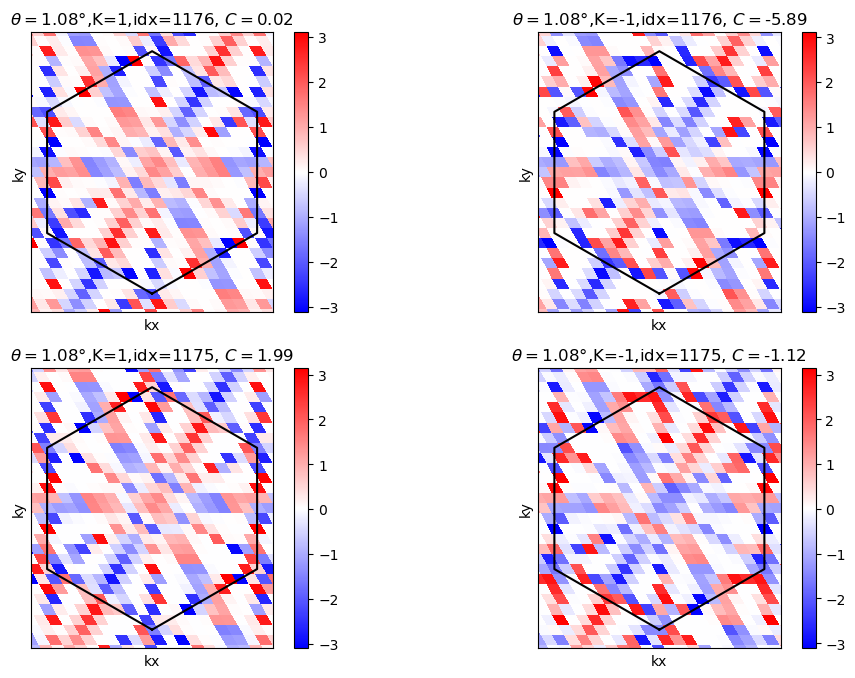

In [84]:
compare_bc(sub_pot=sub_pot,n=19)

#### Test 6-layers

In [23]:
nlayer = 6; theta = f_theta(30)
Ndim = ((2*Qcut+1)**2)*2*nlayer

100%|██████████| 51/51 [00:01<00:00, 33.93it/s]


-0.0017263820364061314

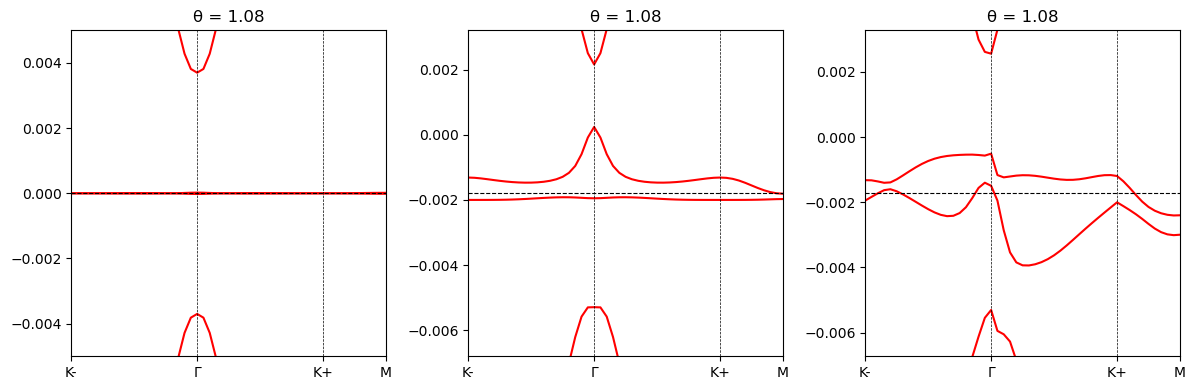

In [26]:
fig = plt.figure(figsize=(12,4))
sub_pot=[2e-3,-2e-3]
# disorder = np.random.uniform(-2e-3,2e-3,(2,2))
disorder = np.array([[2e-3+1j*2e-3,2e-3+1j*2e-3],
                     [2e-3-1j*2e-3,-2e-3+1j*2e-3]])
plt.subplot(1,3,1)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1])
plt.subplot(1,3,2)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],sub_pot=sub_pot)
plt.subplot(1,3,3)
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

In [65]:
np.geomspace(1,1e5,20)

array([1.00000000e+00, 1.83298071e+00, 3.35981829e+00, 6.15848211e+00,
       1.12883789e+01, 2.06913808e+01, 3.79269019e+01, 6.95192796e+01,
       1.27427499e+02, 2.33572147e+02, 4.28133240e+02, 7.84759970e+02,
       1.43844989e+03, 2.63665090e+03, 4.83293024e+03, 8.85866790e+03,
       1.62377674e+04, 2.97635144e+04, 5.45559478e+04, 1.00000000e+05])

In [69]:
# disorder = np.array([[2e-2+1j*2e-2,2e-2+1j*2e-2],
                     # [2e-2-1j*2e-2,2e-2+1j*2e-2]])
disorder = np.array([[4e-2+1j*4e-2,0],
                     [0,1e-2+1j*1e-2]])
disorder

array([[0.04+0.04j, 0.  +0.j  ],
       [0.  +0.j  , 0.01+0.01j]])

100%|██████████| 51/51 [00:01<00:00, 33.56it/s]


0.000694534125949214

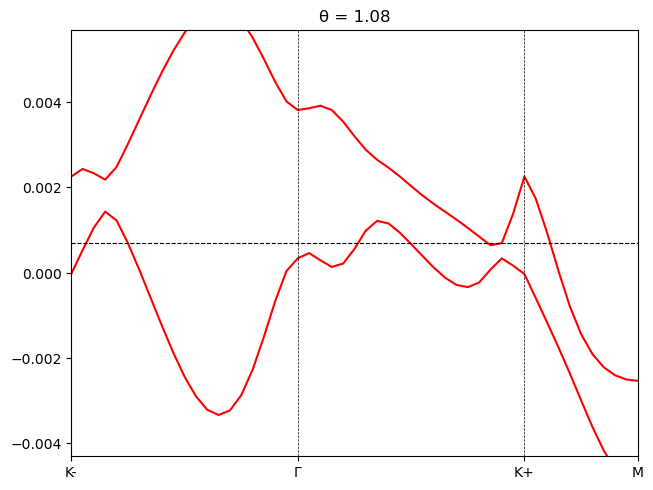

In [70]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:19<00:00,  1.56it/s]


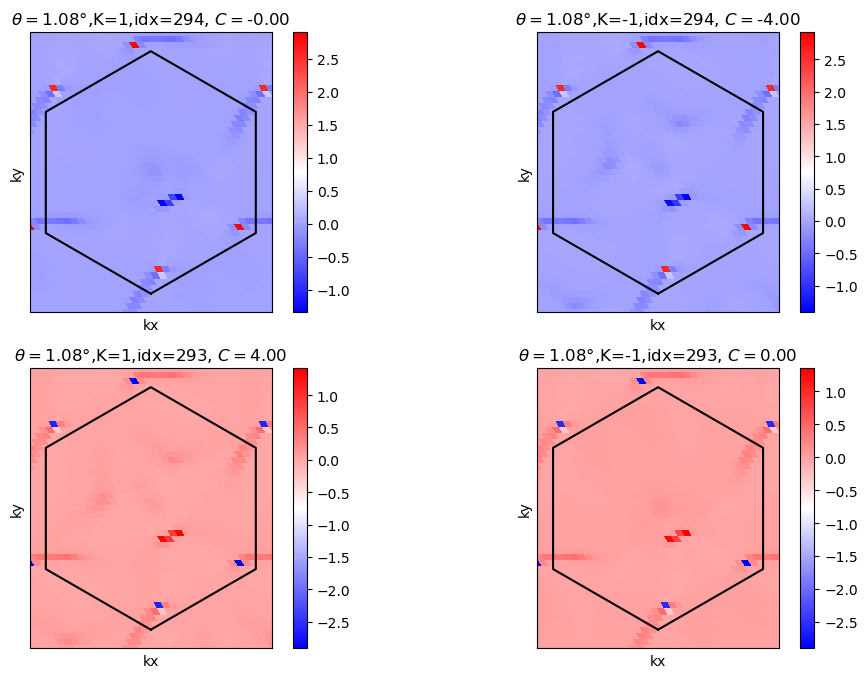

In [71]:
compare_bc(disorder=disorder,n=31)

In [62]:
# disorder = np.array([[2e-2+1j*2e-2,2e-2+1j*2e-2],
                     # [2e-2-1j*2e-2,2e-2+1j*2e-2]])
disorder = np.array([[2e-2+1j*2e-2,0],
                     [0,2e-2+1j*2e-2]])
disorder

array([[0.02+0.02j, 0.  +0.j  ],
       [0.  +0.j  , 0.02+0.02j]])

100%|██████████| 51/51 [00:01<00:00, 34.51it/s]


0.0008869004598461293

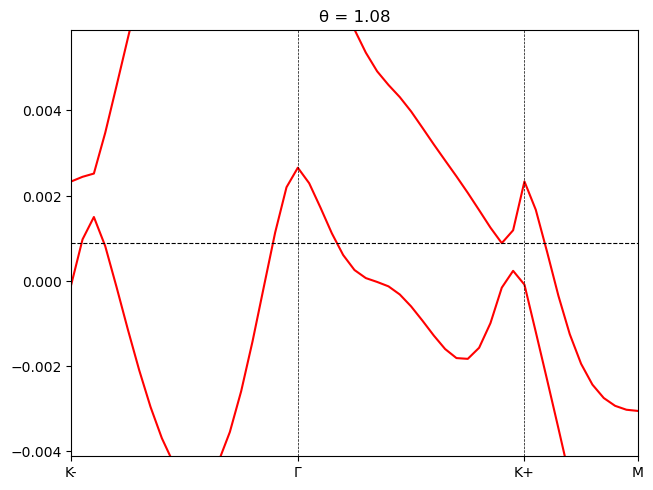

In [63]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:21<00:00,  1.43it/s]


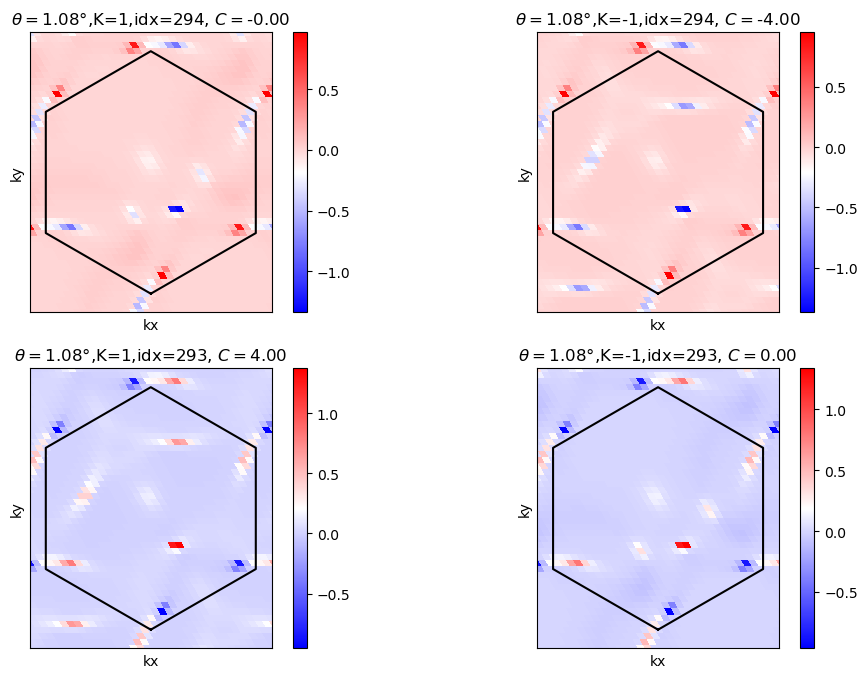

In [64]:
compare_bc(disorder=disorder,n=31)

In [73]:
# disorder = np.array([[2e-2+1j*2e-2,2e-2+1j*2e-2],
                     # [2e-2-1j*2e-2,2e-2+1j*2e-2]])
disorder = np.array([[0,2e-2+1j*2e-2],
                     [2e-2-1j*2e-2,0]])
disorder

array([[0.  +0.j  , 0.02+0.02j],
       [0.02-0.02j, 0.  +0.j  ]])

100%|██████████| 51/51 [00:01<00:00, 35.67it/s]


-0.0005441540384224253

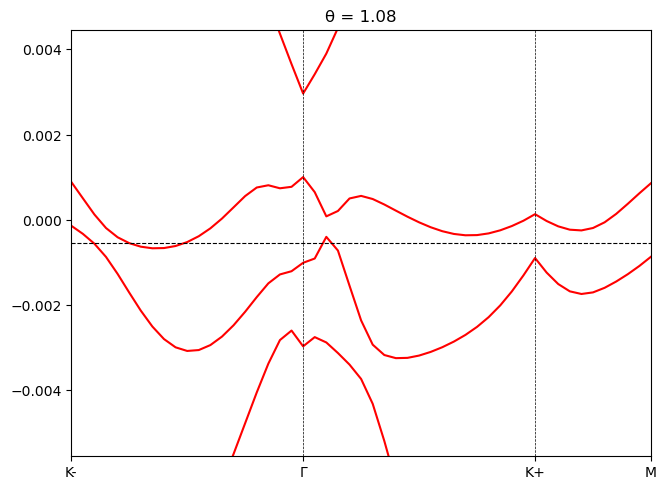

In [74]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:19<00:00,  1.59it/s]


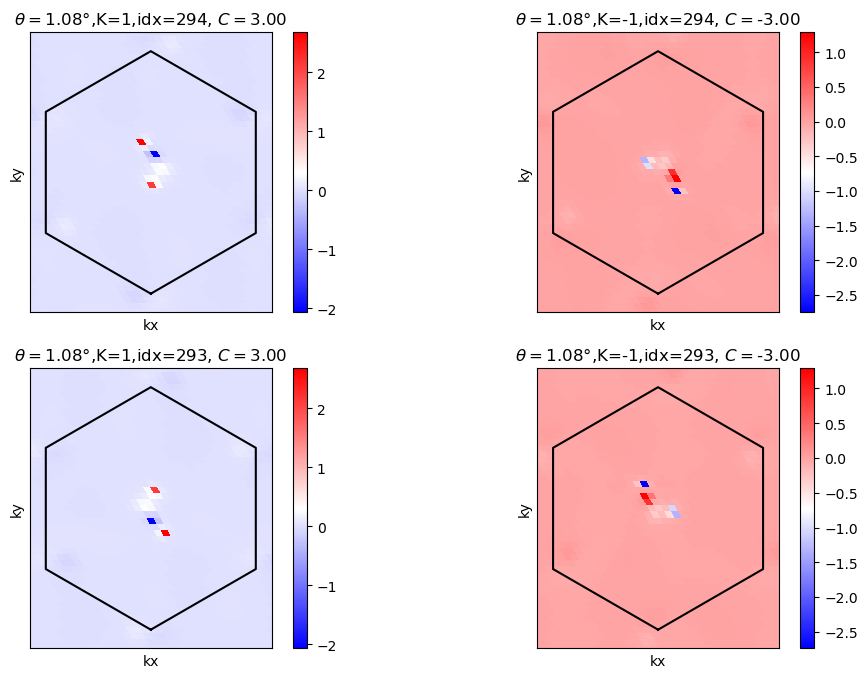

In [75]:
compare_bc(disorder=disorder,n=31)

In [59]:
# disorder = np.array([[2e-2+1j*2e-2,2e-2+1j*2e-2],
                     # [2e-2-1j*2e-2,2e-2+1j*2e-2]])
disorder = np.array([[0,2e-2+1j*2e-2],
                     [2e-2-1j*2e-2,0]])
disorder

array([[0.  +0.j  , 0.02+0.02j],
       [0.02-0.02j, 0.  +0.j  ]])

100%|██████████| 51/51 [00:01<00:00, 34.50it/s]


-0.0005441540384224253

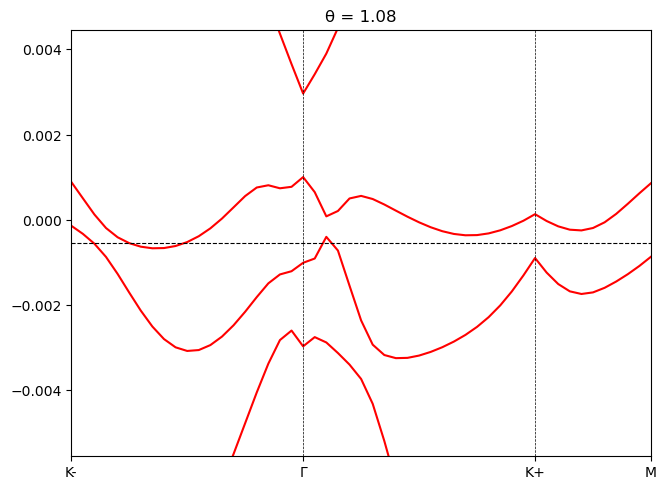

In [60]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:20<00:00,  1.54it/s]


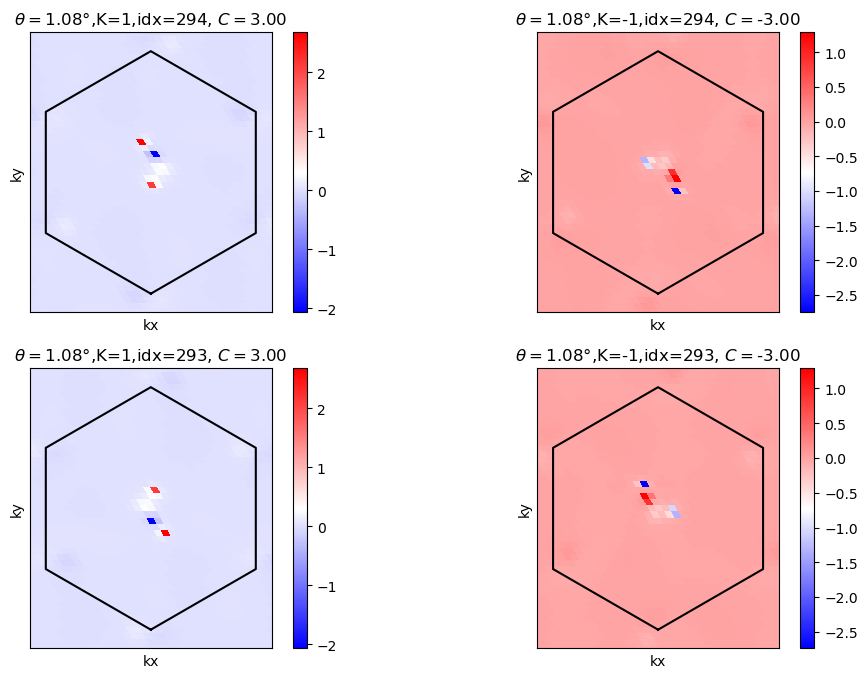

In [61]:
compare_bc(disorder=disorder,n=31)

100%|██████████| 51/51 [00:01<00:00, 33.95it/s]


2.8725338262056366e-05

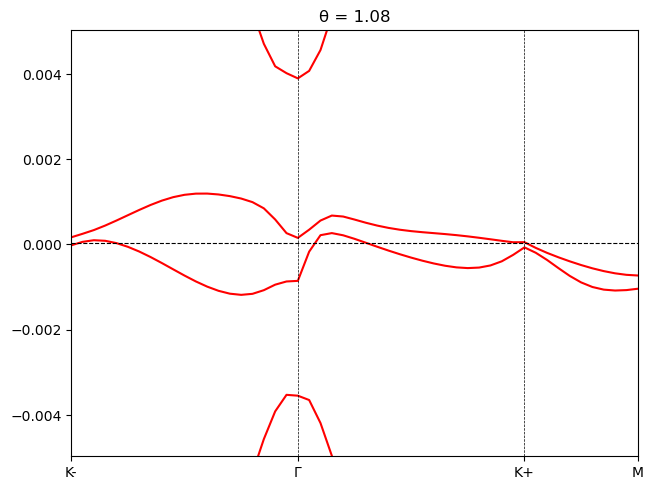

In [43]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:19<00:00,  1.55it/s]


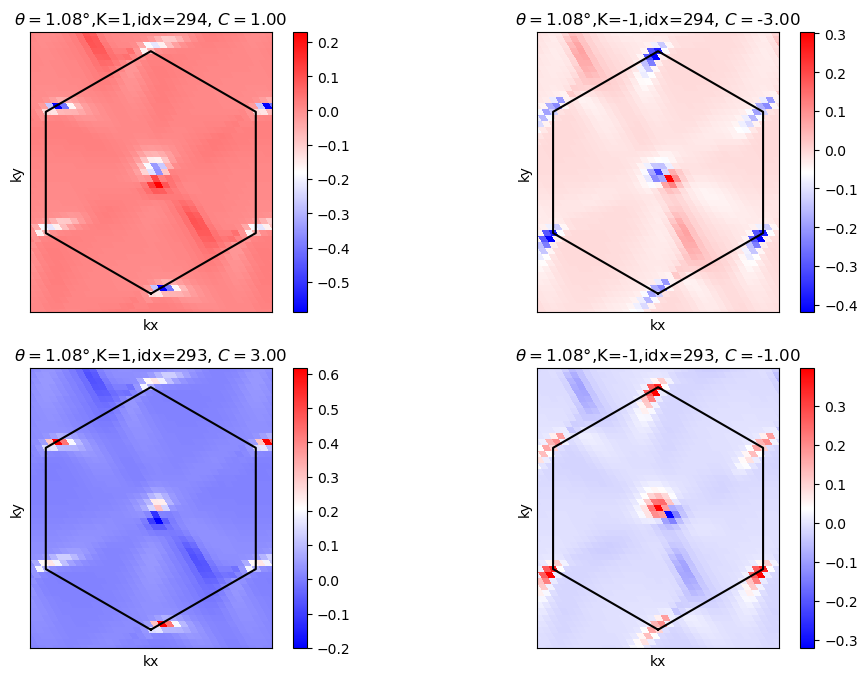

In [44]:
compare_bc(disorder=disorder,n=31)

100%|██████████| 51/51 [00:01<00:00, 34.64it/s]


0.002000006234383814

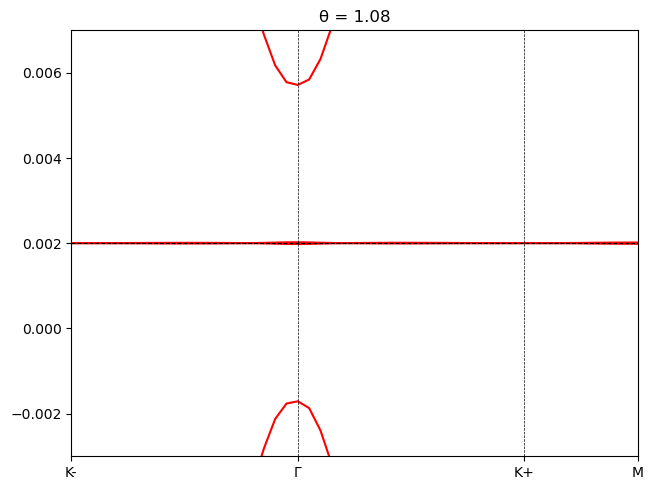

In [39]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:20<00:00,  1.49it/s]


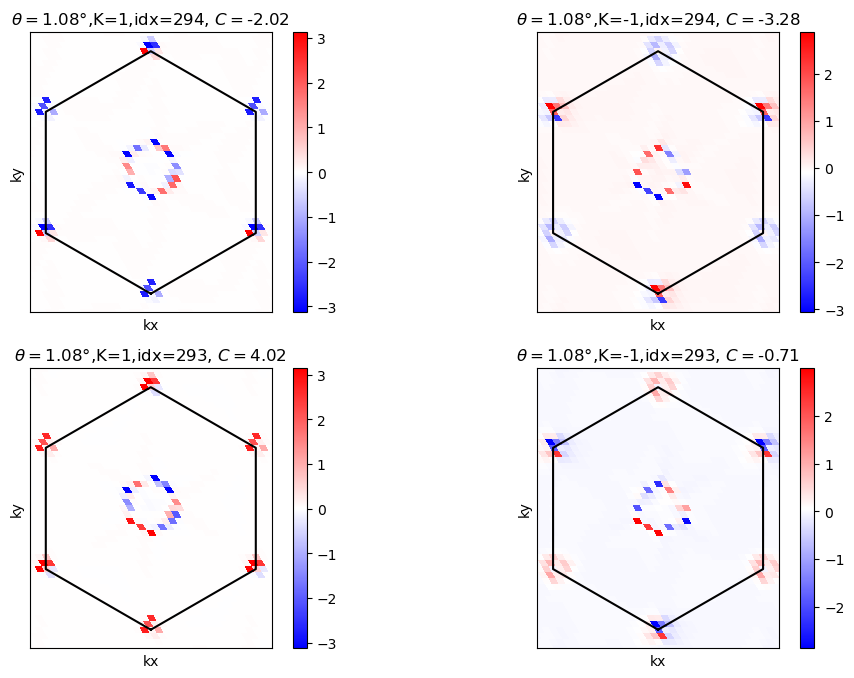

In [40]:
compare_bc(disorder=disorder,n=31)

100%|██████████| 51/51 [00:01<00:00, 35.11it/s]


0.0019993070321860994

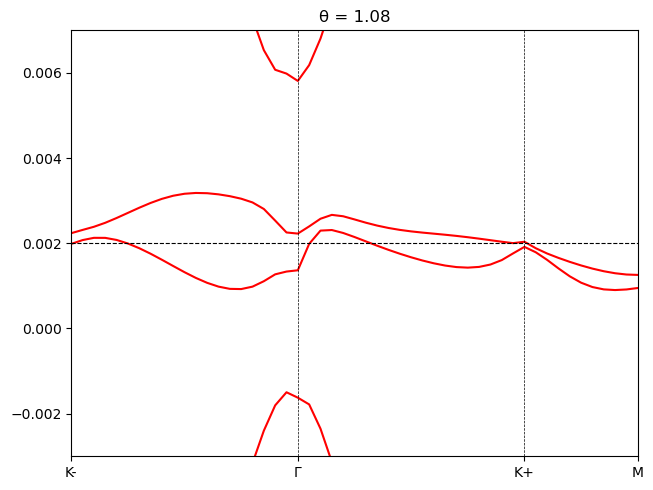

In [33]:
plot_bs(km,theta,nlayer,Er=0.005,valley=[1],disorder=disorder)

100%|██████████| 31/31 [00:21<00:00,  1.48it/s]


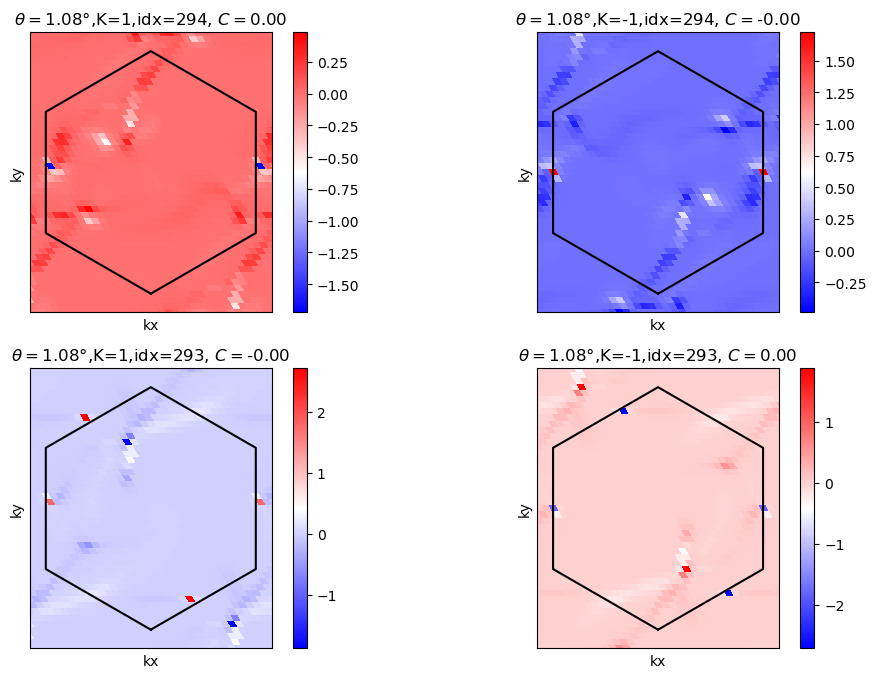

In [30]:
compare_bc(disorder=np.random.uniform(-2e-1,2e-1,(2,2)),n=31)

100%|██████████| 31/31 [00:20<00:00,  1.48it/s]


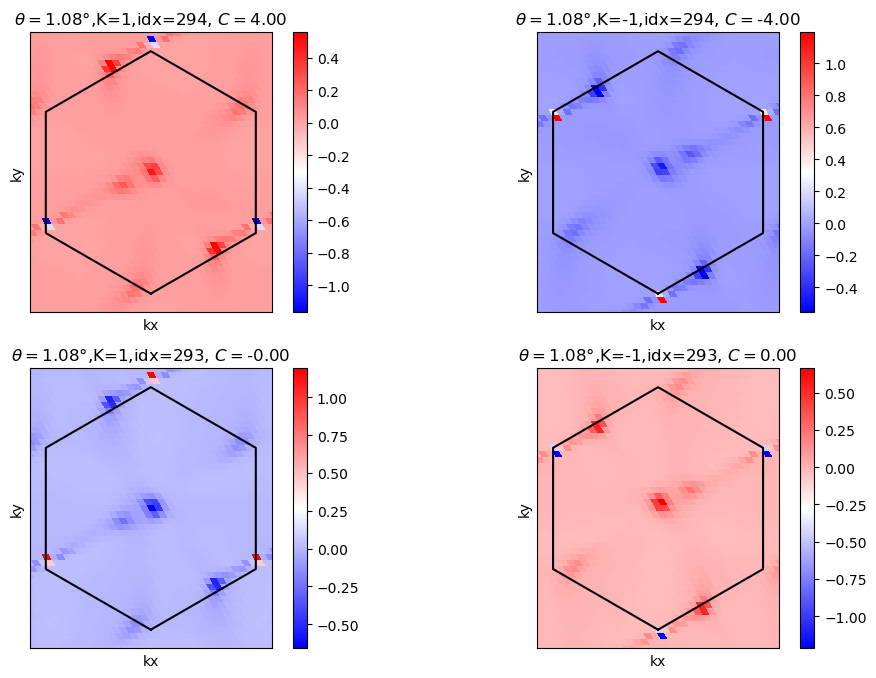

In [31]:
compare_bc(disorder=np.random.uniform(-2e-2,2e-2,(2,2)),n=31)

100%|██████████| 31/31 [00:20<00:00,  1.49it/s]


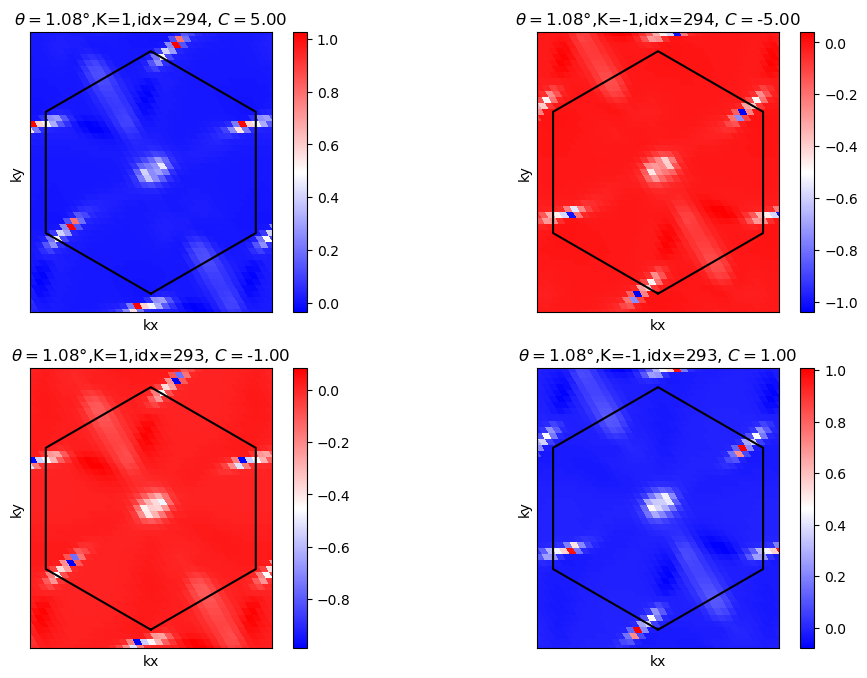

In [32]:
compare_bc(disorder=np.random.uniform(-2e-3,2e-3,(2,2)),n=31)

### Wavefunction distribution

In [53]:
def cal_wave(km,theta,valley=1,idx=1,sub_pot=[0,0],disorder=0,p_bar=1):
    from scipy.linalg import eigh
    bar = tqdm if p_bar else np.array
    th = np.deg2rad(theta)
    vecs = []
    
    for k in bar(km):
        Hk = get_hk(k,valley,th,sub_pot=sub_pot)+disorder
        _, vec = eigh(Hk, subset_by_index=[idx,idx])
        vecs.append(vec)

    vecs = np.array(vecs).squeeze() # e.g. (51,196,1)
    return vecs
    

In [290]:
def plot_amplitude(vecs,nlayer):
    # prob_ldos = np.abs(vecs)**2
    amplitude = np.sum(np.abs(vecs),axis=0)
    amplitude = amplitude.reshape(-1,vecs.shape[-1]//nlayer).sum(axis=1)
    plt.plot(np.arange(nlayer), amplitude)
    plt.xlabel('layers')
    plt.ylabel('amplitude')
    plt.title(f'The {vecs.shape[-1]//2}th band distribution along z-axis')

100%|██████████| 51/51 [00:49<00:00,  1.04it/s]


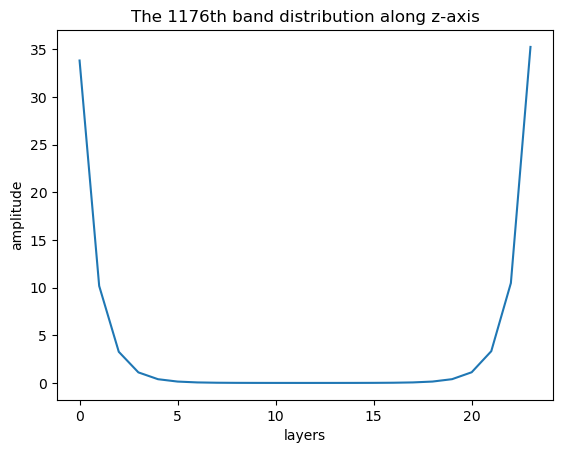

In [291]:
nlayer, ang, seq, ratio = system_in(24,twist=0)
Ndim = ((2*Qcut+1)**2)*2*nlayer
vecs = cal_wave(km,1,idx=Ndim//2)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:48<00:00,  1.05it/s]


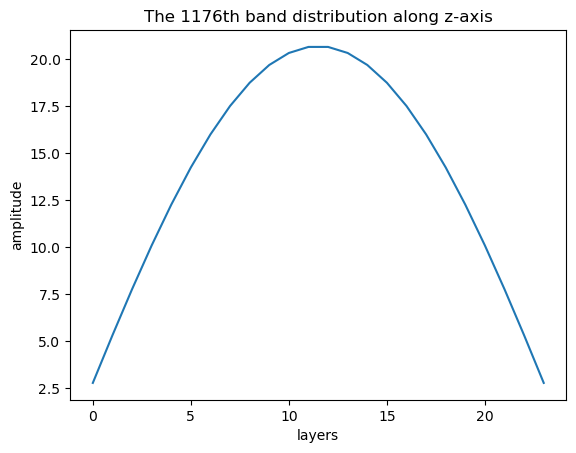

In [292]:
nlayer, ang, seq, ratio = system_in(24,twist=0)
Ndim = ((2*Qcut+1)**2)*2*nlayer
vecs = cal_wave(km,30,idx=Ndim//2)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:03<00:00, 13.04it/s]


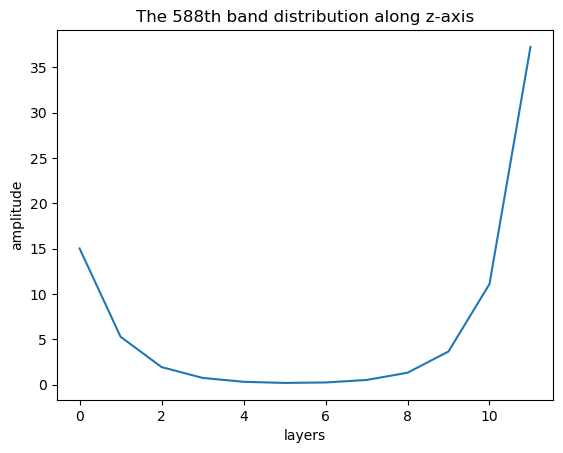

In [297]:
nlayer, ang, seq, ratio = system_in(12,twist=0)
Ndim = ((2*Qcut+1)**2)*2*nlayer
disorder = rand_disorder(1e-4)
vecs = cal_wave(km,1,idx=Ndim//2,disorder=disorder)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:50<00:00,  1.01it/s]


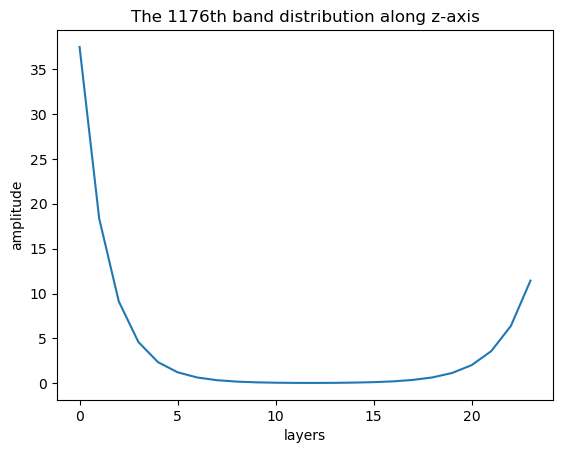

In [298]:
nlayer, ang, seq, ratio = system_in(24,twist=0)
Ndim = ((2*Qcut+1)**2)*2*nlayer
disorder = rand_disorder(1e-5)
vecs = cal_wave(km,1,idx=Ndim//2,disorder=disorder)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:49<00:00,  1.02it/s]


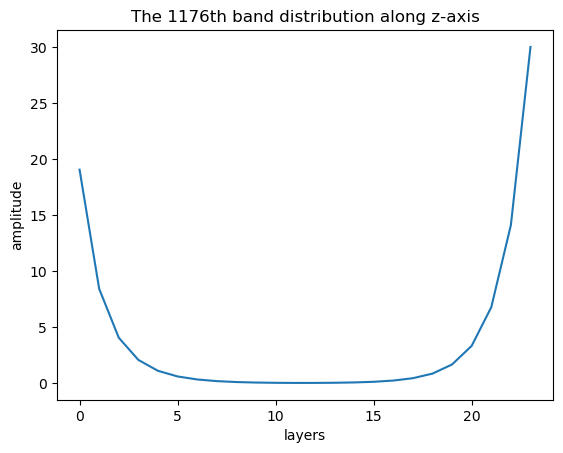

In [299]:
nlayer, ang, seq, ratio = system_in(24,twist=0)
Ndim = ((2*Qcut+1)**2)*2*nlayer
disorder = rand_disorder(1e-5)
vecs = cal_wave(km,1,idx=Ndim//2,disorder=disorder)

plot_amplitude(vecs,nlayer)

#### TB test

In [91]:
def make_graphene(nlayer,re_mat=[1,1,1]):
    from numpy import array, diag, prod
    # stacking = [int(order[i]) for i in range(len(order))] # order='123'
    stacking = np.arange(nlayer)
    xy_mat = re_mat[:-1]; re_mat[-1] = len(stacking); xy_mat.append(1)
    _P = hexagonal_P(crystal=[a,a,dc*len(stacking)],vacuum_z=False)
    _xyz = []
    for i in range(len(stacking)):
        _xy = []
        for s in range(2):
            _x = (stacking[i]+s)%3
            _y = (_x*2)%3
            _xy.append([_x/3,_y/3,(i*2+1)/len(stacking)/2])
        _xyz.append(build_super_cell(xy_mat,_P,array(_xy)@_P)[0])
        
    return (array(_xyz)).reshape(2*prod(re_mat),3), _P@diag(xy_mat)

In [92]:
def translate(original_position,translate_vector):
    x,y,z = translate_vector
    translate_matrix = np.array([[1,0,0,x],
                                 [0,1,0,y],
                                 [0,0,1,z],
                                 [0,0,0,1]])
    original_position = np.c_[original_position, np.ones_like(original_position[:,0])].T
    return (translate_matrix@original_position).T[:,:-1]

def rotate(original_position,angle,rotate_axis=[0,0,1],dimensions='3D'):
    from numpy import cos,sin
    a,b,c = rotate_axis
    th = np.deg2rad(angle)
    rotation_matrix = np.array([[a*a+(1-a*a)*cos(th),a*b*(1-cos(th))+c*sin(th),a*c*(1-cos(th))-b*sin(th),0],
                                [a*b*(1-cos(th))-c*sin(th),b*b+(1-b*b)*cos(th),b*c*(1-cos(th))+a*sin(th),0],
                                [a*c*(1-cos(th))+b*sin(th),b*c*(1-cos(th))-a*sin(th),c*c+(1-c*c)*cos(th),0],
                                [0,0,0,1]])
    if dimensions == '3D':
        original_position = np.c_[original_position,np.zeros_like(original_position[:,0])].T
        return (rotation_matrix@original_position).T[:,:-1]
    elif dimensions == '2D':
        original_position = np.c_[original_position,np.zeros_like(original_position[:,0]),np.zeros_like(original_position[:,0])].T
        return (rotation_matrix@original_position).T[:,:-2]
    else:
        raise ImportError('input position shape does not fit!')

In [93]:
def honeycombe_grids(lattice,const=2.46,dim=2,reverse=False,center=0):
    n = int(np.max(np.abs(lattice/const)))+1
    l = np.linspace(-n+1,n,2*n)
    grid = np.meshgrid(l+center//6-1/6*center,l+center//2-1/2*center)

    Vx = np.array([grid[0],grid[0]-0.5]).flatten()*np.sqrt(3)
    Vy = np.array([grid[1],grid[1]-0.5]).flatten()
    x = np.array([Vx+1/np.sqrt(3)*np.cos(i*np.pi/3) for i in range(2)]).flatten()
    y = np.array([Vy+1/np.sqrt(3)*np.sin(i*np.pi/3) for i in range(2)]).flatten()

    if reverse:
        x,y = y,x
    if dim == 2:
        return np.c_[x,y]*const
    elif dim == 3:
        return np.c_[x,y,np.zeros_like(x)]*const

In [152]:
def make_tTRG(m=10,layer=1,start=0,twist=1,tri_lattice=False):
    k = 2*m+1
    n = np.sqrt(m**2+k**2-2*m*k*np.cos(np.pi/3))
    P = hexagonal_P(np.array([a*n,a*n,dc*layer]))
    vec_c = rotate(np.array([[a/2/np.sqrt(3),a/2,dc]]),twist*f_theta(m)/2)[0]
    if tri_lattice:
        P[-1] = vec_c*layer
    else:
        vec_c = np.array([0,0,dc])
    xyz = []
    for i in range(layer):
        grid = rotate(honeycombe_grids(P,dim=3,center=start+i),twist*f_theta(m)/2)
        grid[:,-1] = dc*i
        xyz.append(grid)
    xyz = np.array(xyz)
    xyz = xyz.reshape(xyz.size//3,3)
    xyz = translate(xyz,vec_c/2+1e-12)
    xyz = np.delete(xyz@np.linalg.inv(P),np.where((xyz@np.linalg.inv(P)>1)|(xyz@np.linalg.inv(P)<0)),axis=0)@P
    return xyz,P

In [95]:
def make_poscar(position,P,file='POSCAR'):
    poscar = open(file,'w')
    print("TBG"+"\n1.000",file=poscar)
    print('\t%.15f' % P[0][0], '\t%.15f' % P[0][1], '\t%.15f' % P[0][2], file=poscar)
    print('\t%.15f' % P[1][0], '\t%.15f' % P[1][1], '\t%.15f' % P[1][2], file=poscar)
    print('\t%.15f' % P[2][0], '\t%.15f' % P[2][1], '\t%.15f' % P[2][2], file=poscar)
    print('C\n','%s\n'%position.shape[0],'C',file=poscar)
    for i in range(position.shape[0]):
        print('\t%.15f'%position[i][0],'\t%.15f'% position[i][1],'\t%.15f'% position[i][2],file=poscar)
    poscar.close()

In [96]:
def bravis(dim=2,lack_axis=-1):
    if lack_axis == -1:
        lack_axis = dim
    import itertools
    neighbour = np.array([-1,0,1])
    bravis = np.array(list(itertools.product(neighbour,repeat=dim)))
    bravis = np.insert(bravis, lack_axis, np.zeros((3-dim,3**dim)), axis=1)
    return bravis

def t(d):
    a0 = a/np.sqrt(3); delta_0 = 0.184*a
    r = np.linalg.norm(d,axis=-1)
    Vppp = -2.7 * np.exp(-(r - a0) / delta_0)
    Vpps = 0.48 * np.exp(-(r - dc) / delta_0)
    np.seterr(invalid='ignore')
    return Vppp*(1-(d[...,-1]/r)**2)+Vpps*(d[...,-1]/r)**2

In [97]:
def hopping(xyz,R,cutoff=4*a0):
    dis_mat = xyz[None,:,None,:]-xyz[None,None,:,:]+R[:,None,None,:]
    eff_dis = np.linalg.norm(dis_mat,axis=-1)<=cutoff
    hopping = np.nan_to_num(t(dis_mat))*eff_dis
    return hopping

In [98]:
def tb_wave(nlayer,sub_pot=[0,0],disorder=0,p_bar=1):
    from scipy.linalg import eigh
    bar = tqdm if p_bar else np.array
    
    xyz,P = make_graphene(nlayer,re_mat=[5,5,1])
    R = bravis(2)@P
    hop = hopping(xyz,R)
    # B = 2*np.pi*np.linalg.inv(P).T
    hyk = list(map(high_sym_k(P,frac=0).get, xtk))
    kpath,xtp = gen_kpath(hyk,51,return_ticks_points=True)
    idx = xyz.shape[0]//2
    
    vecs = []
    
    for k in bar(kpath):
        Hk = np.sum(hop*(np.exp(1j*(R@k))[:,None,None]),axis=0)+disorder
        _, vec = eigh(Hk, subset_by_index=[idx,idx])
        vecs.append(vec)

    vecs = np.array(vecs).squeeze() # e.g. (51,196,1)
    return vecs

In [164]:
def tb_model(m=10,nlayer=4,xtk=['K','Γ','Ks','M'],n=100,which='top',mode='band'):
    import scipy as sp
    from scipy.sparse.linalg import eigsh
    
    xyz,P = make_tTRG(m,nlayer)
    na = xyz.shape[0]; R = bravis(2)@P; hop = hopping(xyz,R)
    idx = 0 if which == 'top' else -1

    K = high_sym_k(P,frac=False)['K']
    HK = np.sum(hop*(np.exp(1j*(R@K))[:,None,None]),axis=0)
    Ef,_ = sp.linalg.eigh(HK,subset_by_index=[na//2-idx,na//2-idx])

    if mode == 'band':
        hyk = list(map(high_sym_k(P,frac=0).get, xtk))
        kpath,xtp = gen_kpath(hyk,n,return_ticks_points=True)
    
        eigval = []
        for k in kpath:
            H = np.sum(hop*(np.exp(1j*(R@k))[:,None,None]),axis=0)
            val,vec = eigsh(H,k=16,sigma=Ef)
            eigval.append(val)
    
        eigval = np.array(eigval)
        for band in eigval.T:
            plt.scatter(range(len(kpath)),band-Ef,c='k',s=1)
    
        plt.xticks(xtp,xtk)
    elif mode == 'chern':
        from numpy.linalg import det as det

        kx = np.linspace(0,np.pi,n)
        ky = np.linspace(0,np.pi,n)*2/np.sqrt(3)
        kx,ky = kx/P[0,0],ky/P[0,0]

        BC = np.zeros((n-1,n-1))
        vecs = np.zeros((n,n,na,1),dtype=complex)
        k = np.linspace(0,1,n)
        
        for i in tqdm(range(n)):
            for j in range(n):
                H = np.sum(hop*(np.exp(1j*(R@[kx[i],ky[j],0]))[:,None,None]),axis=0)
                val, vec = eigsh(H,k=1,sigma=Ef)
                # val, vec = sp.linalg.eigh(H,subset_by_index=[na//2-1,na//2-1])
                vecs[i,j] = vec[:,np.argsort(val.real)]
                
        for i in range(n-1):
            for j in range(n-1):
                line1 = vecs[i,j].conj().T@vecs[i+1,j]
                line2 = vecs[i+1,j].conj().T@vecs[i+1,j+1]
                line3 = vecs[i+1,j+1].conj().T@vecs[i,j+1]
                line4 = vecs[i,j+1].conj().T@vecs[i,j]
                phi = -np.angle(det(line1)*det(line2)*det(line3)*det(line4))
                BC[i,j] = phi

        _k = np.linspace(-1,1,2*n-2,endpoint=False)
        X,Y = np.meshgrid(_k,_k)

        C = np.sum(BC)/2/np.pi
        plt.pcolormesh(X,Y,np.tile(BC.T,(2,2)),cmap='bwr')
        plt.title(fr'$\theta=${f_theta(m):.2f}°, nlayer={nlayer}, $C=${C:.2f}')
        plt.xlabel('kx');plt.ylabel('ky')
        plt.xticks([]);plt.yticks([])
        plt.axis('scaled')
        plt.colorbar()
        
    # return 0

100%|██████████| 51/51 [16:34<00:00, 19.50s/it]


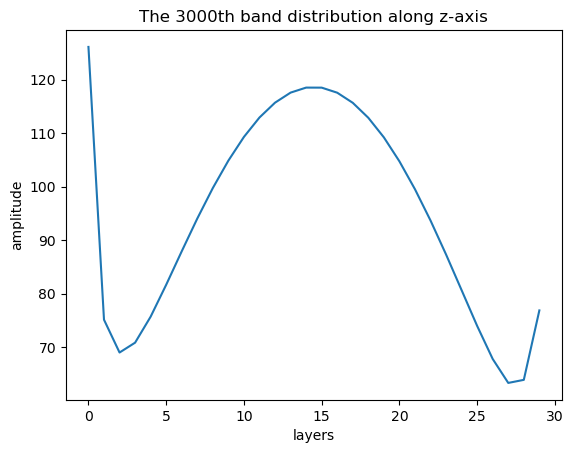

In [308]:
nlayer = 30
vecs = tb_wave(nlayer)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:13<00:00,  3.68it/s]


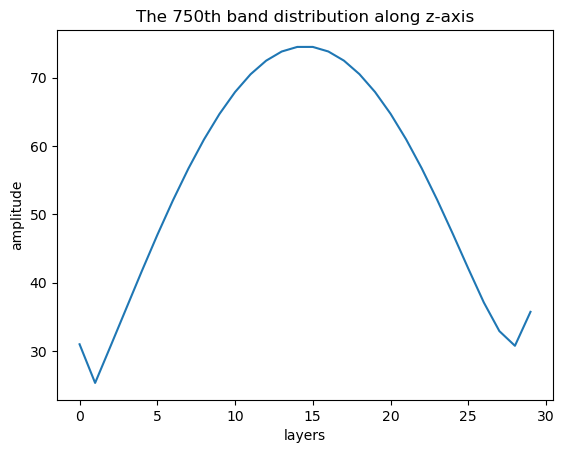

In [310]:
nlayer = 30
vecs = tb_wave(nlayer)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:40<00:00,  1.27it/s]


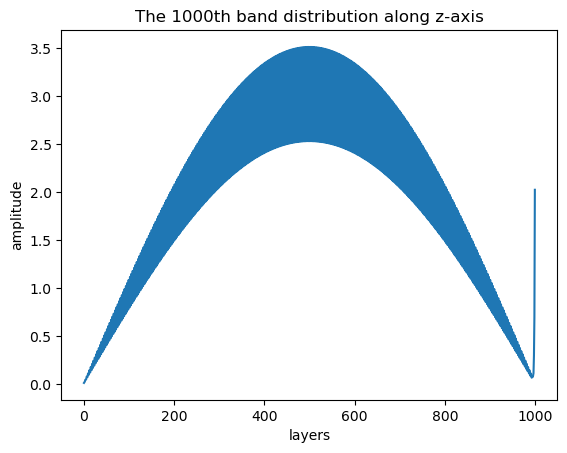

In [294]:
nlayer = 1000
vecs = tb_wave(nlayer)

plot_amplitude(vecs,nlayer)

100%|██████████| 51/51 [00:39<00:00,  1.28it/s]


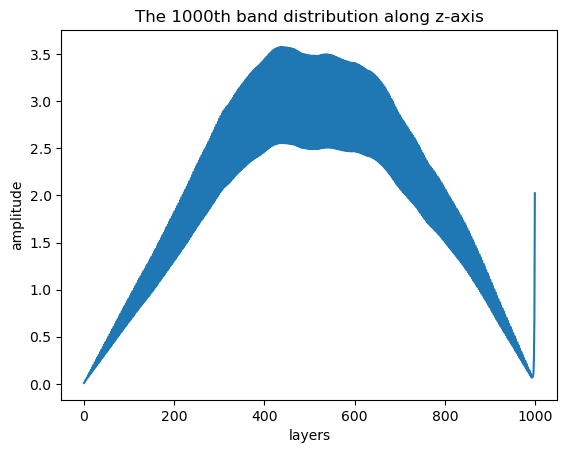

In [295]:
nlayer = 1000
disorder = rand_disorder(1e-5,ndim=nlayer*2)
vecs = tb_wave(nlayer,disorder=disorder)

plot_amplitude(vecs,nlayer)